In [134]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# **Ref, Sav 데이터프레임 정리하기**
- Reference data
    - 팀 컬럼 필요: 25시즌 승률 5할 이상인 팀 + 마이애미
    - 선발, 불펜 구별 변수 필요
    - 이닝 수 , 기타 기본 투수 지표 필요 
- Savant data
    - 심화된 투수 지표 필요: "velocity", "spin_rate", "release_extension", "xwoba", "xba", "xslg", "launch_speed" "hardhit_percent", "barrels_per_bbe_percent", "swing_miss_percent", "pitcher_run_value_per_100"

In [135]:
years = [2021, 2022, 2023, 2024, 2025]

data_dir = r"C:\Users\ddaen\OneDrive\Desktop\비어플"


In [136]:
# 시즌별 승률 5할 이상 팀
# Miami는 비교팀(ref)에서는 제외하고, 따로 Miami 데이터로 분리할 예정
ref_teams_by_year = {
    2021: ["TOR", "TBR", "BOS", "NYY", "CHW", "HOU", "OAK", "SEA",
           "ATL", "PHI", "MIL", "STL", "CIN", "LAD", "SFG"],

    2022: ["TOR", "BAL", "TBR", "NYY", "CLE", "CHW", "HOU", "SEA",
           "ATL", "NYM", "PHI", "MIL", "STL", "LAD", "SFG", "SDP"],

    2023: ["TOR", "BAL", "TBR", "NYY", "MIN", "HOU", "SEA", "TEX",
           "ATL", "PHI", "MIL", "CHC", "CIN", "ARI", "LAD", "SDP"],

    2024: ["BAL", "BOS", "NYY", "CLE", "KCR", "DET", "MIN", "HOU", "SEA",
           "ATL", "NYM", "PHI", "MIL", "STL", "CHC", "ARI", "LAD", "SDP"],

    2025: ["TOR", "NYY", "BOS", "CLE", "DET", "KCR", "SEA", "HOU", "TEX",
           "PHI", "NYM", "MIL", "CHC", "CIN", "LAD", "SDP", "SFG"]
}

In [137]:
# reference에서 사용할 컬럼
keep_cols_ref = [
    "season",
    "Player",
    "Team",
    "Age",
    "G",
    "GS",
    "GF",
    "SV",
    "IP",
    "WAR",
    "FIP",
    "WHIP",
    "HR9",
    "SO/BB"
]

# savant에서 사용할 컬럼
keep_cols_sav = [
    "season",
    "player_name",
    "k_percent",
    "bb_percent",
    "velocity",
    "spin_rate",
    "release_extension",
    "xwoba",
    "xba",
    "xslg",
    "launch_speed",
    "hardhit_percent",
    "barrels_per_bbe_percent",
    "swing_miss_percent",
    "pitcher_run_value_per_100"
]

In [138]:
def clean_ref_name(name):
    if pd.isna(name):
        return name
    
    return (
        str(name)
        .replace("*", "")
        .replace("#", "")
        .strip()
        .lower()
    )


def clean_savant_name(name):
    if pd.isna(name):
        return name
    
    name = str(name).strip()
    
    # Savant가 "Last, First" 형태면 "First Last"로 바꾸기
    if "," in name:
        last, first = name.split(",", 1)
        name = f"{first.strip()} {last.strip()}"
    
    return name.lower()

In [139]:
# 이름 표기 차이 수동 보정
manual_name_map = {
    "ranger suárez": "ranger suarez",
    "adrián morejón": "adrian morejon",
    "hector neris": "héctor neris",
    "lázaro estrada": "lazaro estrada",
    "kiké hernández": "enrique hernández",
    "ezequiel durán": "ezequiel duran",
    "josé corniell": "jose corniell",
    "reiver sanmartín": "reiver sanmartin",
    "jesús tinoco": "jesus tinoco",
    "luarbert árias": "luarbert arias"
}

In [140]:
# reference 21~25 불러오기
ref_list = []

for year in years:
    yy = str(year)[-2:]
    file_path = os.path.join(data_dir, f"reference_{yy}_clustering.csv")
    
    print(file_path)
    
    temp = pd.read_csv(file_path)
    temp["season"] = year
    
    ref_list.append(temp)

ref_all = pd.concat(ref_list, ignore_index=True)

ref_all.head()

C:\Users\ddaen\OneDrive\Desktop\비어플\reference_21_clustering.csv
C:\Users\ddaen\OneDrive\Desktop\비어플\reference_22_clustering.csv
C:\Users\ddaen\OneDrive\Desktop\비어플\reference_23_clustering.csv
C:\Users\ddaen\OneDrive\Desktop\비어플\reference_24_clustering.csv
C:\Users\ddaen\OneDrive\Desktop\비어플\reference_25_clustering.csv


,Rk,Player,Age,Team,Lg,WAR,W,L,W-L%,ERA,...,FIP,WHIP,H9,HR9,BB9,SO9,SO/BB,Awards,Player-additional,season
0,1.0,Zack Wheeler,31.0,PHI,NL,7.5,14.0,10.0,0.583,2.78,...,2.59,1.008,7.1,0.7,1.9,10.4,5.37,ASCYA-2MVP-19,wheelza01,2021
1,2.0,Walker Buehler,26.0,LAD,NL,7.1,16.0,4.0,0.800,2.47,...,3.16,0.968,6.5,0.8,2.3,9.2,4.08,ASCYA-4,buehlwa01,2021
2,3.0,Adam Wainwright,39.0,STL,NL,3.7,17.0,7.0,0.708,3.05,...,3.66,1.057,7.3,0.9,2.2,7.6,3.48,CYA-7MVP-20,wainwad01,2021
3,4.0,Sandy Alcantara,25.0,MIA,NL,4.2,9.0,15.0,0.375,3.19,...,3.42,1.075,7.5,0.9,2.2,8.8,4.02,NaN,alcansa01,2021
4,5.0,Robbie Ray*,29.0,TOR,AL,6.9,13.0,7.0,0.650,2.84,...,3.69,1.045,7.0,1.5,2.4,11.5,4.77,CYA-1MVP-15,rayro02,2021


In [141]:
ref_all.shape
ref_all["season"].value_counts().sort_index()

season
2021    1153
2022    1068
2023    1065
2024    1095
2025    1151
Name: count, dtype: int64

In [142]:
# savant 21-25 불러오기
sav_list = []

for year in years:
    yy = str(year)[-2:]
    file_path = os.path.join(data_dir, f"savant_{yy}_clustering.csv")
    
    print(file_path)
    
    temp = pd.read_csv(file_path)
    temp["season"] = year
    
    sav_list.append(temp)

sav_all = pd.concat(sav_list, ignore_index=True)

sav_all.head()

C:\Users\ddaen\OneDrive\Desktop\비어플\savant_21_clustering.csv
C:\Users\ddaen\OneDrive\Desktop\비어플\savant_22_clustering.csv
C:\Users\ddaen\OneDrive\Desktop\비어플\savant_23_clustering.csv
C:\Users\ddaen\OneDrive\Desktop\비어플\savant_24_clustering.csv
C:\Users\ddaen\OneDrive\Desktop\비어플\savant_25_clustering.csv


,pitches,player_id,player_name,total_pitches,pitch_percent,ba,iso,babip,slg,woba,...,wobadiff,swing_miss_percent,arm_angle,attack_angle,attack_direction,swing_path_tilt,rate_ideal_attack_angle,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches,season
0,2746,554430,"Wheeler, Zack",3209,85.6,0.225,0.099,0.299,0.324,0.264,...,-0.003,25.2,37.6,NaN,NaN,NaN,NaN,NaN,NaN,2021
1,2315,458681,"Lynn, Lance",2613,88.6,0.211,0.128,0.271,0.339,0.266,...,0.008,26.5,33.0,NaN,NaN,NaN,NaN,NaN,NaN,2021
2,2285,645261,"Alcantara, Sandy",3098,73.8,0.218,0.146,0.256,0.364,0.275,...,-0.013,26.3,34.3,NaN,NaN,NaN,NaN,NaN,NaN,2021
3,2147,621111,"Buehler, Walker",3160,67.9,0.214,0.154,0.245,0.368,0.291,...,-0.024,22.4,50.6,NaN,NaN,NaN,NaN,NaN,NaN,2021
4,1983,593423,"Montas, Frankie",3032,65.4,0.261,0.165,0.298,0.426,0.326,...,-0.017,21.2,51.4,NaN,NaN,NaN,NaN,NaN,NaN,2021


In [143]:
sav_all.shape
sav_all["season"].value_counts().sort_index()

season
2021    478
2022    467
2023    467
2024    536
2025    555
Name: count, dtype: int64

# **Ref & Sav 하나의 데이터프레임으로 합치기**

In [144]:
def clean_ref_name(name):
    if pd.isna(name):
        return name
    
    return (
        str(name)
        .replace("*", "")
        .replace("#", "")
        .strip()
        .lower()
    )


def clean_savant_name(name):
    if pd.isna(name):
        return name
    
    name = str(name).strip()
    
    # "Last, First" 형태면 "First Last"로 바꾸기
    if "," in name:
        last, first = name.split(",", 1)
        name = f"{first.strip()} {last.strip()}"
    
    return name.lower()

In [145]:
ref_all["name_key"] = ref_all["Player"].apply(clean_ref_name)
sav_all["name_key"] = sav_all["player_name"].apply(clean_savant_name)

In [146]:
pitcher_cluster = pd.merge(
    ref_all,
    sav_all,
    on=["season", "name_key"],
    how="inner",
    suffixes=("_ref", "_sav")
)

pitcher_cluster.shape

(3304, 116)

In [147]:
keep_cols = [
    "season",
    
    # 식별용
    "player_name",
    "Team",
    "Age",

    # 선발/불펜 구분용
    "G",
    "GS",
    "GF",
    "SV",
    "IP",

    # reference 지표
    "WAR",
    "FIP",
    "WHIP",
    "HR9",
    "SO/BB",

    # savant 지표
    "k_percent",
    "bb_percent",
    "velocity",
    "spin_rate",
    "release_extension",
    "xwoba",
    "xba",
    "xslg",
    "launch_speed",
    "hardhit_percent",
    "barrels_per_bbe_percent",
    "swing_miss_percent",
    "pitcher_run_value_per_100"
]

pitcher_cluster = pitcher_cluster[keep_cols].copy()
pitcher_cluster.shape

(3304, 27)

In [148]:
pitcher_cluster.columns

Index(['season', 'player_name', 'Team', 'Age', 'G', 'GS', 'GF', 'SV', 'IP',
       'WAR', 'FIP', 'WHIP', 'HR9', 'SO/BB', 'k_percent', 'bb_percent',
       'velocity', 'spin_rate', 'release_extension', 'xwoba', 'xba', 'xslg',
       'launch_speed', 'hardhit_percent', 'barrels_per_bbe_percent',
       'swing_miss_percent', 'pitcher_run_value_per_100'],
      dtype='object')

In [149]:
pitcher_cluster["is_miami"] = pitcher_cluster["Team"] == "MIA"

pitcher_cluster["is_ref"] = pitcher_cluster.apply(
    lambda row: row["Team"] in ref_teams_by_year[row["season"]],
    axis=1
)

In [150]:
miami_pitcher = pitcher_cluster[
    pitcher_cluster["is_miami"]
].copy()

ref_pitcher = pitcher_cluster[
    (pitcher_cluster["is_ref"]) &
    (~pitcher_cluster["is_miami"])
].copy()

In [151]:
# 2TM 합산 행 제거
pitcher_cluster = pitcher_cluster[pitcher_cluster["Team"] != "2TM"].copy()

# Miami 여부
pitcher_cluster["is_miami"] = pitcher_cluster["Team"] == "MIA"

# 시즌별 ref 팀 여부
pitcher_cluster["is_ref"] = pitcher_cluster.apply(
    lambda row: row["Team"] in ref_teams_by_year[row["season"]],
    axis=1
)

# ref도 아니고 Miami도 아닌 행 제거
pitcher_cluster = pitcher_cluster[
    (pitcher_cluster["is_ref"]) | (pitcher_cluster["is_miami"])
].copy()

In [152]:
pitcher_cluster[
    (~pitcher_cluster["is_ref"]) &
    (~pitcher_cluster["is_miami"])
][["season", "Team", "player_name"]].drop_duplicates()

,season,Team,player_name


# **선발 / 불펜 투수 구분하기**
- 선발 / 불펜 투수 따로 클러스터링이 필요한 이유:
    - 선발투수는 보통 IP, GS, starter_ratio, ip_per_game이 크고, 긴 이닝을 안정적으로 먹는 것이 중요.
    - 반면 불펜투수는 짧은 이닝에서 구위, 헛스윙, 피장타 억제, 불펜 역할이 더 중요.
    - 그러므로 둘을 같이 클러스터링하면 모델이 “잘 던지는 유형”을 찾기보다 그냥 선발 vs 불펜 차이만 보고 군집을 나눠버릴 가능성이 큼.

## 선발 / 불펜 투수 구분하는 파생변수 만들기
- 선발 등판 경기 수 10 이상인가? + 불펜보다 선발로 나온 경기 비중이 더 큰가?

In [153]:
# 선발 투수 등판 비율
pitcher_cluster["starter_ratio"] = pitcher_cluster["GS"] / pitcher_cluster["G"]

# 경기당 이닝 소화 수
pitcher_cluster["ip_per_game"] = pitcher_cluster["IP"] / pitcher_cluster["G"]

In [154]:
pitcher_cluster["role"] = np.where(
    (pitcher_cluster["GS"] >= 10) & 
    (pitcher_cluster["starter_ratio"] >= 0.5),
    "starter",
    "reliever"
)

In [155]:
pitcher_cluster.to_csv("pitcher_cluster.csv", index=False, encoding="utf-8-sig")

## Miami / 비교팀 분할하기

In [156]:
teams_500 = [
    "TOR", "NYY", "BOS", "CLE", "DET", "KCR", "SEA", "HOU", "TEX",
    "PHI", "NYM", "MIL", "CHC", "CIN", "LAD", "SDP", "SFG"
]

miami_pitcher = pitcher_cluster[pitcher_cluster["Team"] == "MIA"].copy()

ref_pitcher = pitcher_cluster[pitcher_cluster["Team"].isin(teams_500)].copy()

## 선발 / 불펜 투수로 분할하기
- Miami 전체: 31 명
- Miami 선발: 6 명
- Miami 중간: 25 명
- 비교팀 전체: 564 명
- 비교팀 선발: 102 명
- 비교팀 중간: 462 명

In [157]:
# Miami 선발 투수
miami_starter = miami_pitcher[miami_pitcher["role"] == "starter"].copy()

# Miami 불펜 투수
miami_reliever = miami_pitcher[miami_pitcher["role"] == "reliever"].copy()

# 비교팀 (승률 5할 이상 17팀) 선발 투수
ref_starter = ref_pitcher[ref_pitcher["role"] == "starter"].copy()

# 비교팀 (승률 5할 이상 17팀) 불펜 투수
ref_reliever = ref_pitcher[ref_pitcher["role"] == "reliever"].copy()

In [158]:
# 전체 역할 개수 확인
print("Miami 전체:", miami_pitcher.shape[0],"명")
print("Miami 선발:", miami_starter.shape[0],"명")
print("Miami 중간:", miami_reliever.shape[0],"명")

print("비교팀 전체:", ref_pitcher.shape[0],"명")
print("비교팀 선발:", ref_starter.shape[0],"명")
print("비교팀 중간:", ref_reliever.shape[0],"명")

# 팀별 역할 개수 확인:
pitcher_cluster.groupby(["Team", "role"]).size()

Miami 전체: 150 명
Miami 선발: 31 명
Miami 중간: 119 명
비교팀 전체: 1736 명
비교팀 선발: 344 명
비교팀 중간: 1392 명


Team  role    
ARI   reliever     32
      starter       6
ATL   reliever     81
      starter      22
BAL   reliever     68
      starter      17
BOS   reliever     82
      starter      16
CHC   reliever     55
      starter      13
CHW   reliever     35
      starter      10
CIN   reliever     53
      starter      11
CLE   reliever     63
      starter      18
DET   reliever     52
      starter      12
HOU   reliever    102
      starter      30
KCR   reliever     44
      starter      11
LAD   reliever    131
      starter      34
MIA   reliever    119
      starter      31
MIL   reliever    117
      starter      28
MIN   reliever     28
      starter       7
NYM   reliever     94
      starter      17
NYY   reliever    113
      starter      30
OAK   reliever     20
      starter       5
PHI   reliever     99
      starter      24
SDP   reliever     70
      starter      24
SEA   reliever    113
      starter      30
SFG   reliever     74
      starter      14
STL   reliever   

# **클러스터링용 최종 변수 결정하기**
- war 제외: WAR은 FIP, IP, 실점 억제, 삼진/볼넷 같은 결과가 합쳐진 종합 성과 지표이기 때문에 포함 시 
    단순히 “잘함/못함”으로 나뉠 가능성이 있음
- SO/BB 제외: k_percent, bb_percent와 겹침
- xba 제외: xwoba, xslg으로 충분히 설명 가능
- 투수 성능/구위/타구질 변수 위주로 넣기
- 선발은 50이닝, 불펜은 20이닝 기준 이하 선수 제외
- X_ref_starter = 클러스터링에 실제로 넣는 숫자 데이터
- ref_starter_model = 선수 이름, 팀, WAR, cluster 결과까지 보려고 남기는 데이터

In [159]:
features = [
    #성능
    "IP",
    "FIP",
    "WHIP",
    "HR9",

    #구위
    "k_percent",
    "bb_percent",
    "velocity",
    "spin_rate",
    "release_extension",
    
    #타구질
    "xwoba",
    "xslg",
    "launch_speed",
    "hardhit_percent",
    "barrels_per_bbe_percent",
    "swing_miss_percent",
    "pitcher_run_value_per_100"
]

In [160]:
ref_starter_model = ref_starter.dropna(subset=features).copy()
ref_reliever_model = ref_reliever.dropna(subset=features).copy()

miami_starter_model = miami_starter.dropna(subset=features).copy()
miami_reliever_model = miami_reliever.dropna(subset=features).copy()

In [161]:
# 최소 이닝 기준 넣기
ref_starter_model = ref_starter_model[ref_starter_model["IP"] >= 50].copy()
miami_starter_model = miami_starter_model[miami_starter_model["IP"] >= 50].copy()

ref_reliever_model = ref_reliever_model[ref_reliever_model["IP"] >= 30].copy()
miami_reliever_model = miami_reliever_model[miami_reliever_model["IP"] >= 30].copy()

In [162]:
X_ref_starter = ref_starter_model[features].copy()
X_ref_reliever = ref_reliever_model[features].copy()

X_miami_starter = miami_starter_model[features].copy()
X_miami_reliever = miami_reliever_model[features].copy()

# **클러스터링 하기**
- 변수 분포 확인
- 왜도 큰 변수 변환
- 표준화
- VIF 확인
- VIF 높으면 PCA 진행 후 클러스터링
- KMeans 클러스터링

## 변수 분포 확인

- 선발: 전체적으로 분포가 안정적이며, 클러스터링에 큰 영향을 줄 만한 극단값은 많지 않은 것으로 확인됨.
- 불펜: 일부 변수에서 극단값이 확인되어, 클러스터링 전 개별 선수와 지표를 추가로 확인함..
- `spin_rate` 변수 제외 결정:
    - `spin_rate`는 투수의 평균 회전수를 나타내지만, 투수마다 주로 사용하는 구종이 다르기 때문에 단순 평균값만으로 구위를 비교하기 어렵다.
    - 특히 스플리터, 체인지업, 싱커 등 특정 구종을 많이 던지는 투수는 회전수가 낮게 나타날 수 있어, 낮은 `spin_rate`가 반드시 낮은 능력을 의미하지 않는다.
    - 이미 `velocity`, `k_percent`, `swing_miss_percent`, `pitcher_run_value_per_100` 등 구위를 설명할 수 있는 변수가 포함되어 있으므로, 중복성과 해석 왜곡 가능성을 줄이기 위해 `spin_rate`는 최종 클러스터링 변수에서 제외하였다.

In [163]:
import matplotlib.pyplot as plt
import math

def plot_feature_distribution_grid(df, features, ncols=4, bins=20, figsize_per_plot=(4, 3)):
    n = len(features)
    nrows = math.ceil(n / ncols)
    
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows)
    )
    
    axes = axes.flatten()
    
    for i, col in enumerate(features):
        axes[i].hist(df[col].dropna(), bins=bins)
        axes[i].set_title(col, fontsize=10)
        axes[i].set_xlabel(col, fontsize=9)
        axes[i].set_ylabel("count", fontsize=9)
    
    # 남는 축 제거
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

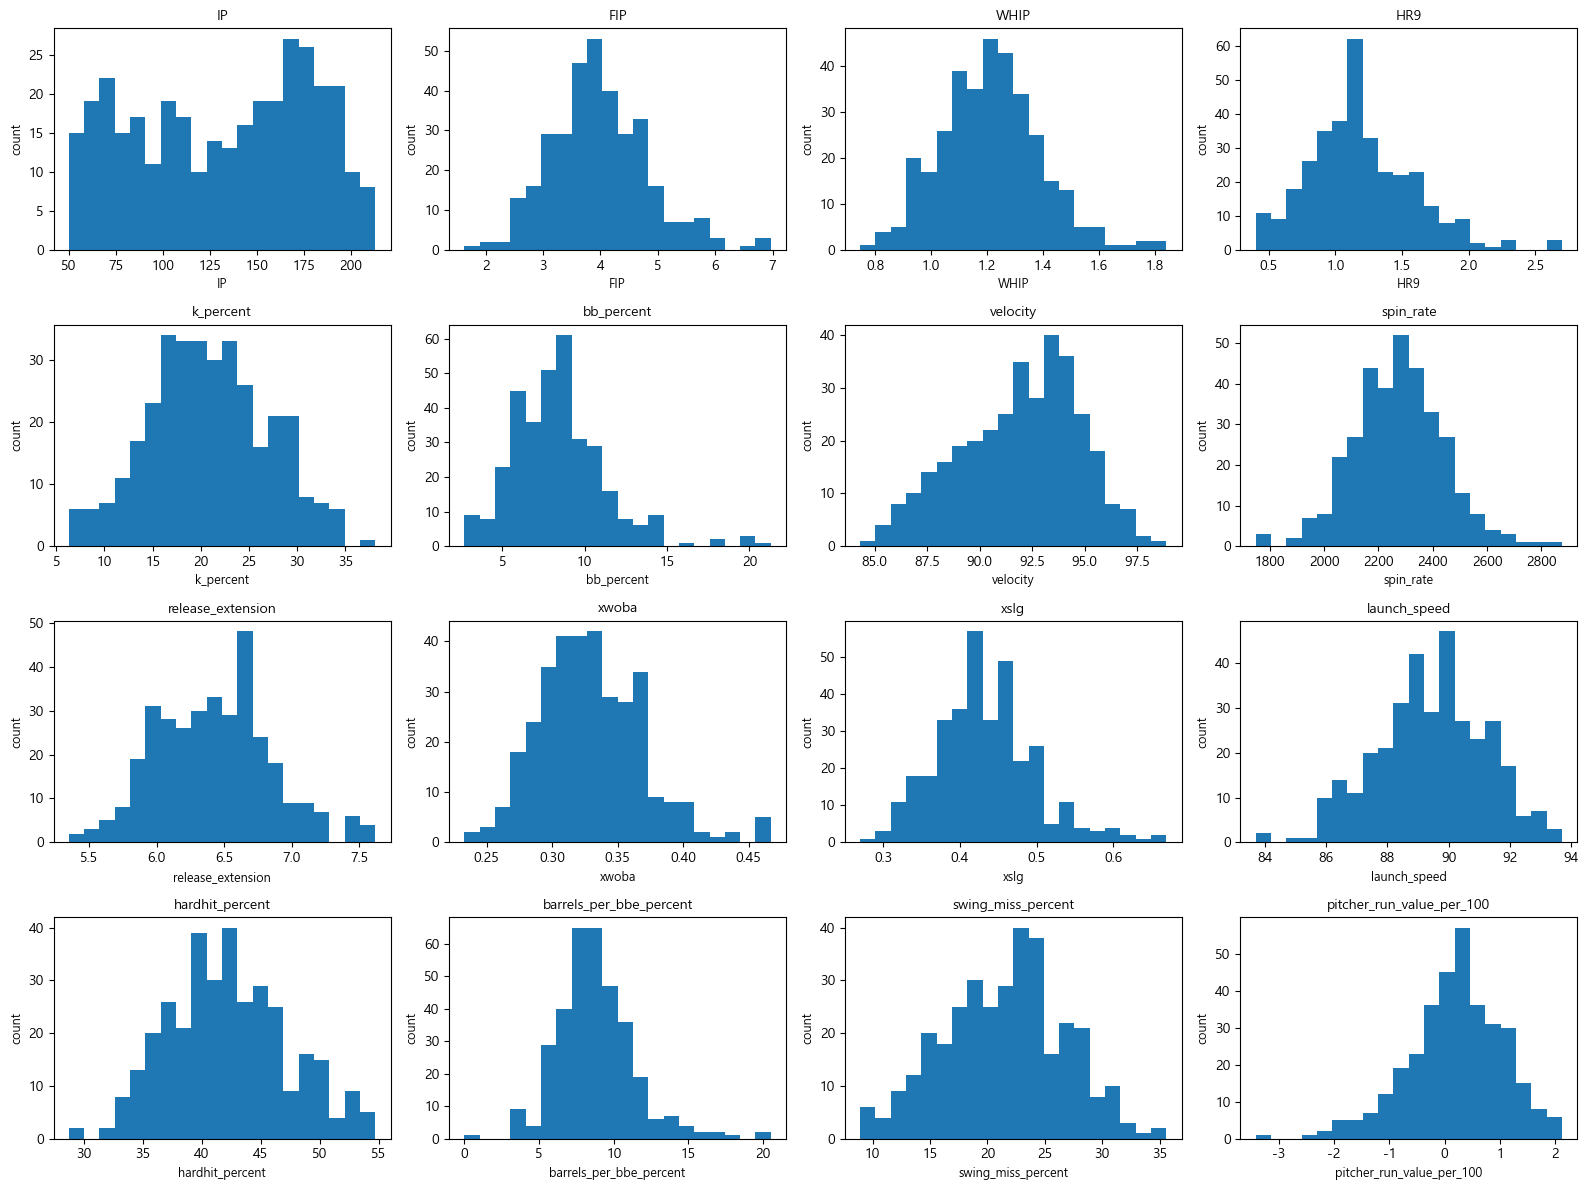

In [164]:
# 선발 분포 확인
plot_feature_distribution_grid(X_ref_starter, features, ncols=4, bins=20)

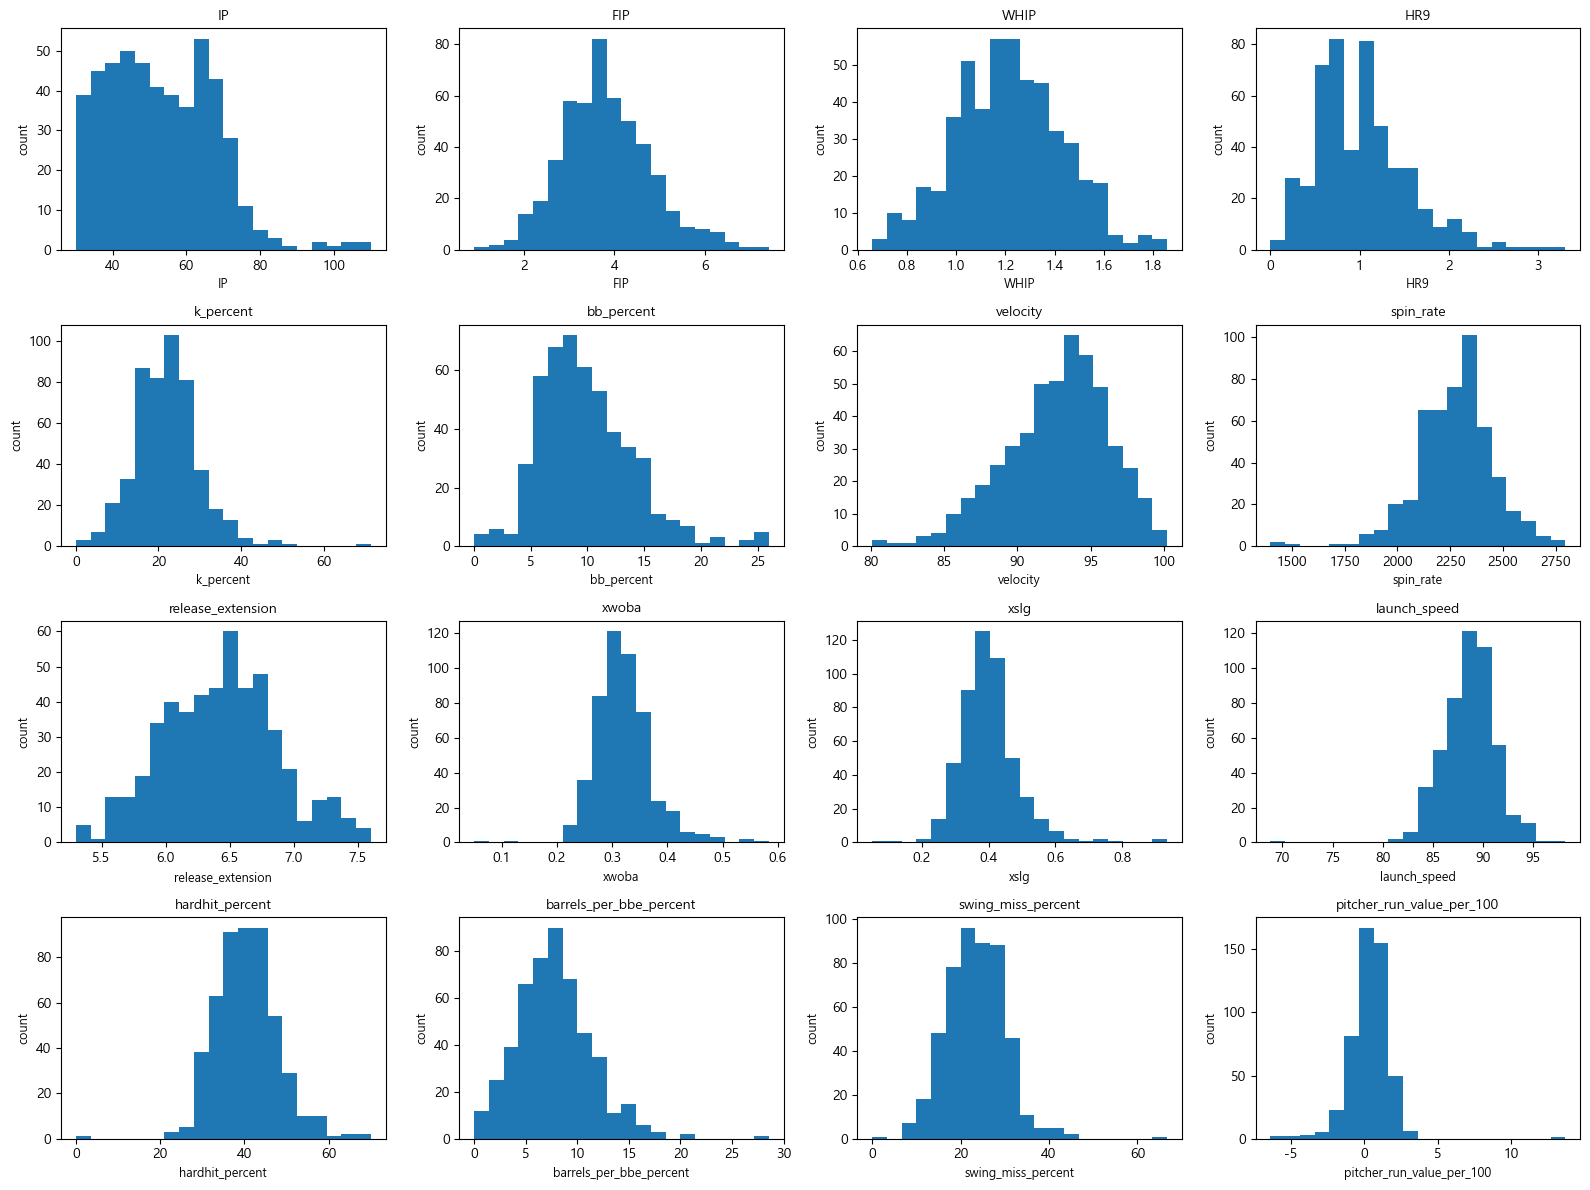

In [165]:
# 중간 분포 확인
plot_feature_distribution_grid(X_ref_reliever, features, ncols=4, bins=20)

In [166]:
# 1. 최종 features 다시 정의
features = [
    "IP",
    "FIP",
    "WHIP",
    "HR9",
    "k_percent",
    "bb_percent",
    "velocity",
    "release_extension",
    "xwoba",
    "xslg",
    "launch_speed",
    "hardhit_percent",
    "barrels_per_bbe_percent",
    "swing_miss_percent",
    "pitcher_run_value_per_100"
]

# 2. X 데이터 다시 생성
X_ref_starter = ref_starter_model[features].copy()
X_ref_reliever = ref_reliever_model[features].copy()

X_miami_starter = miami_starter_model[features].copy()
X_miami_reliever = miami_reliever_model[features].copy()

## 변수 왜도 확인

- 선발: 대부분의 변수 왜도가 -0.5~0.5 근처에 분포하여 전반적으로 안정적인 분포를 보임.


- 불펜: `k_percent`의 왜도가 약 1.03으로 가장 컸는데, 이는 일부 고삼진 불펜 투수들이 존재하기 때문으로 해석되고, 데이터 오류라기보다 실제 투수 유형 차이를 반영하는 값으로 판단되어 제거하지 않았음.


In [167]:
# 선발 왜도 확인
ref_starter_model[features].skew().sort_values(ascending=False)

bb_percent                   1.143611
barrels_per_bbe_percent      0.890173
HR9                          0.712472
xwoba                        0.638602
xslg                         0.588284
FIP                          0.524304
WHIP                         0.388077
release_extension            0.236414
hardhit_percent              0.232043
k_percent                    0.079262
swing_miss_percent          -0.050224
IP                          -0.169710
launch_speed                -0.210237
velocity                    -0.319952
pitcher_run_value_per_100   -0.554536
dtype: float64

In [168]:
# 불펜 왜도 확인
ref_reliever_model[features].skew().sort_values(ascending=False)

xslg                         1.288480
pitcher_run_value_per_100    1.027744
HR9                          0.933631
bb_percent                   0.877051
k_percent                    0.769492
xwoba                        0.763976
barrels_per_bbe_percent      0.719520
swing_miss_percent           0.628772
IP                           0.589435
FIP                          0.417531
hardhit_percent              0.139901
release_extension            0.111603
WHIP                         0.101391
velocity                    -0.543147
launch_speed                -0.844764
dtype: float64

## 표준화
- ref 데이터로 평균/표준편차를 학습하고,
- Miami는 그 ref 기준에 맞춰 변환

In [169]:
def scale_ref_miami(X_ref, X_miami):
    scaler = StandardScaler()
    
    X_ref_scaled = scaler.fit_transform(X_ref)
    X_miami_scaled = scaler.transform(X_miami)
    
    X_ref_scaled = pd.DataFrame(
        X_ref_scaled,
        columns=X_ref.columns,
        index=X_ref.index
    )
    
    X_miami_scaled = pd.DataFrame(
        X_miami_scaled,
        columns=X_miami.columns,
        index=X_miami.index
    )
    
    return X_ref_scaled, X_miami_scaled, scaler

In [170]:
# 선발 표준화
X_ref_starter_scaled, X_miami_starter_scaled, starter_scaler = scale_ref_miami(
    X_ref_starter,
    X_miami_starter
)

In [171]:
# 중간 표준화
X_ref_reliever_scaled, X_miami_reliever_scaled, reliever_scaler = scale_ref_miami(
    X_ref_reliever,
    X_miami_reliever
)

## VIF 확인 및 변수 조정

- `FIP` 제거: 홈런, 볼넷, 삼진 기반 지표이므로 `HR9`, `k_percent`, `bb_percent`와 중복성이 크다.
- `xslg` 제거: 역시 `xwoba` 및 타구질 변수들과 중복성이 높다고 판단하였다.
- 'pitcher_run_value_per_100' 제거: 종합 성과 지표라서 xwoba, WHIP, k_percent, HR9, hardhit_percent랑 겹치는 느낌이 큼.
- 따라서 최종 클러스터링 변수에서는 `FIP`와 `xslg`, 'pitcher_run_value_per_100'를 제외하였다.

In [172]:
def calculate_vif_sklearn(X):
    vif_list = []
    
    for col in X.columns:
        y = X[col]
        X_other = X.drop(columns=[col])
        
        model = LinearRegression()
        model.fit(X_other, y)
        
        r2 = model.score(X_other, y)
        
        if r2 >= 0.999999:
            vif = np.inf
        else:
            vif = 1 / (1 - r2)
        
        vif_list.append([col, vif])
    
    vif_df = pd.DataFrame(vif_list, columns=["feature", "VIF"])
    return vif_df.sort_values("VIF", ascending=False)

- 선발 VIF

In [173]:
starter_vif = calculate_vif_sklearn(X_ref_starter_scaled)
starter_vif

,feature,VIF
8,xwoba,43.970891
9,xslg,42.023632
1,FIP,12.062703
3,HR9,8.015963
4,k_percent,7.004737
12,barrels_per_bbe_percent,4.538169
11,hardhit_percent,4.245917
5,bb_percent,4.157143
10,launch_speed,4.130470
2,WHIP,4.039702


- 중간 VIF

In [174]:
reliever_vif = calculate_vif_sklearn(X_ref_reliever_scaled)
reliever_vif

,feature,VIF
9,xslg,28.195648
8,xwoba,28.077008
1,FIP,7.576365
3,HR9,5.813515
4,k_percent,4.903053
12,barrels_per_bbe_percent,4.235907
5,bb_percent,3.901247
11,hardhit_percent,3.716566
10,launch_speed,3.471061
14,pitcher_run_value_per_100,3.242050


In [175]:
# 1. 최종 features 다시 정의
features = [
    # 성능 / 누적
    "IP",
    "WHIP",
    "HR9",

    # 구위 / 제구
    "k_percent",
    "bb_percent",
    "velocity",
    "release_extension",

    # 타구질
    "xwoba",
    "launch_speed",
    "hardhit_percent",
    "barrels_per_bbe_percent",
    "swing_miss_percent",

]

# 2. X 데이터 다시 생성
X_ref_starter = ref_starter_model[features].copy()
X_ref_reliever = ref_reliever_model[features].copy()

X_miami_starter = miami_starter_model[features].copy()
X_miami_reliever = miami_reliever_model[features].copy()

# 3. 다시 표준화
X_ref_starter_scaled, X_miami_starter_scaled, starter_scaler = scale_ref_miami(
    X_ref_starter,
    X_miami_starter
)

X_ref_reliever_scaled, X_miami_reliever_scaled, reliever_scaler = scale_ref_miami(
    X_ref_reliever,
    X_miami_reliever
)

In [176]:
# VIF 다시 확인
starter_vif = calculate_vif_sklearn(X_ref_starter_scaled)
starter_vif

,feature,VIF
7,xwoba,6.598545
3,k_percent,6.051675
9,hardhit_percent,4.094515
8,launch_speed,3.868803
11,swing_miss_percent,3.550099
10,barrels_per_bbe_percent,2.318350
1,WHIP,2.187678
4,bb_percent,1.742852
2,HR9,1.719213
5,velocity,1.335630


In [177]:
reliever_vif = calculate_vif_sklearn(X_ref_reliever_scaled)
reliever_vif

,feature,VIF
7,xwoba,5.095502
3,k_percent,4.316121
9,hardhit_percent,3.628526
8,launch_speed,3.280412
11,swing_miss_percent,2.378804
10,barrels_per_bbe_percent,2.371338
4,bb_percent,1.568002
1,WHIP,1.540921
2,HR9,1.441017
5,velocity,1.171962


### PCA 진행

In [178]:
def apply_pca_ref_miami(X_ref_scaled, X_miami_scaled, variance_ratio=0.8):
    pca = PCA(n_components=variance_ratio, random_state=42)
    
    X_ref_pca = pca.fit_transform(X_ref_scaled)
    X_miami_pca = pca.transform(X_miami_scaled)
    
    pc_cols = [f"PC{i+1}" for i in range(pca.n_components_)]
    
    X_ref_pca = pd.DataFrame(
        X_ref_pca,
        columns=pc_cols,
        index=X_ref_scaled.index
    )
    
    X_miami_pca = pd.DataFrame(
        X_miami_pca,
        columns=pc_cols,
        index=X_miami_scaled.index
    )
    
    pca_info = pd.DataFrame({
        "PC": pc_cols,
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "cumulative_variance_ratio": np.cumsum(pca.explained_variance_ratio_)
    })
    
    loading = pd.DataFrame(
        pca.components_.T,
        index=X_ref_scaled.columns,
        columns=pc_cols
    )
    
    return X_ref_pca, X_miami_pca, pca, pca_info, loading

- 선발 PCA

In [179]:
X_ref_starter_pca, X_miami_starter_pca, starter_pca, starter_pca_info, starter_loading = apply_pca_ref_miami(
    X_ref_starter_scaled,
    X_miami_starter_scaled,
    variance_ratio=0.8
)

starter_pca_info

,PC,explained_variance_ratio,cumulative_variance_ratio
0,PC1,0.335581,0.335581
1,PC2,0.155982,0.491562
2,PC3,0.121923,0.613485
3,PC4,0.090110,0.703595
4,PC5,0.073765,0.777360
5,PC6,0.064916,0.842276


- 중간 PCA

In [180]:
X_ref_reliever_pca, X_miami_reliever_pca, reliever_pca, reliever_pca_info, reliever_loading = apply_pca_ref_miami(
    X_ref_reliever_scaled,
    X_miami_reliever_scaled,
    variance_ratio=0.8
)

reliever_pca_info

,PC,explained_variance_ratio,cumulative_variance_ratio
0,PC1,0.285253,0.285253
1,PC2,0.153697,0.438950
2,PC3,0.119585,0.558535
3,PC4,0.110853,0.669388
4,PC5,0.076267,0.745656
5,PC6,0.066996,0.812652


- 최종 클러스터링용 변수 지정

In [181]:
X_ref_starter_final = X_ref_starter_pca
X_miami_starter_final = X_miami_starter_pca

X_ref_reliever_final = X_ref_reliever_pca
X_miami_reliever_final = X_miami_reliever_pca

## KMeans 클러스터링

- k 찾는 함수

In [182]:
def check_kmeans_k(X, k_range=range(2, 7)):
    results = []

    for k in k_range:
        model = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = model.fit_predict(X)

        inertia = model.inertia_
        silhouette = silhouette_score(X, labels)

        results.append([k, inertia, silhouette])

    result_df = pd.DataFrame(
        results,
        columns=["k", "inertia", "silhouette_score"]
    )

    return result_df

- 선발 k 확인

In [183]:
starter_k_result = check_kmeans_k(X_ref_starter_final, range(2, 7))
starter_k_result

c:\Users\ddaen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\ddaen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\ddaen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\ddaen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

,k,inertia,silhouette_score
0,2,2605.443041,0.205637
1,3,2312.708456,0.160513
2,4,2071.734979,0.154850
3,5,1879.502931,0.152947
4,6,1776.221748,0.146562


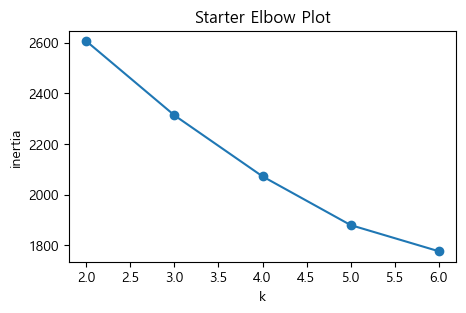

In [184]:
plt.figure(figsize=(5, 3))
plt.plot(starter_k_result["k"], starter_k_result["inertia"], marker="o")
plt.xlabel("k")
plt.ylabel("inertia")
plt.title("Starter Elbow Plot")
plt.show()

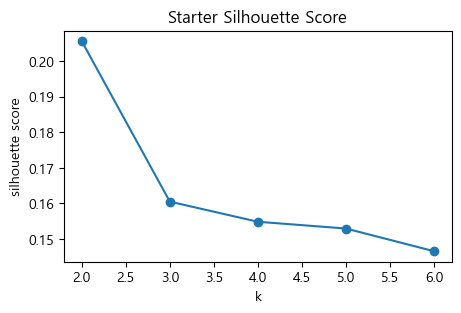

In [185]:
plt.figure(figsize=(5, 3))
plt.plot(starter_k_result["k"], starter_k_result["silhouette_score"], marker="o")
plt.xlabel("k")
plt.ylabel("silhouette score")
plt.title("Starter Silhouette Score")
plt.show()

- 중간 k 확인

In [186]:
reliever_k_result = check_kmeans_k(X_ref_reliever_final, range(2, 7))
reliever_k_result

c:\Users\ddaen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\ddaen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\ddaen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\ddaen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

,k,inertia,silhouette_score
0,2,3816.646854,0.189041
1,3,3397.604721,0.157050
2,4,3125.097414,0.148185
3,5,2880.628701,0.149609
4,6,2682.682605,0.151009


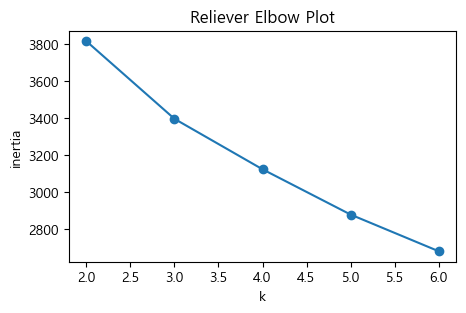

In [187]:
plt.figure(figsize=(5, 3))
plt.plot(reliever_k_result["k"], reliever_k_result["inertia"], marker="o")
plt.xlabel("k")
plt.ylabel("inertia")
plt.title("Reliever Elbow Plot")
plt.show()

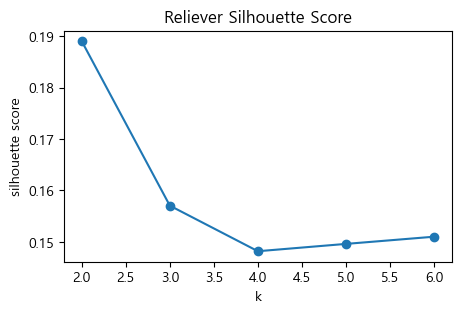

In [188]:
plt.figure(figsize=(5, 3))
plt.plot(reliever_k_result["k"], reliever_k_result["silhouette_score"], marker="o")
plt.xlabel("k")
plt.ylabel("silhouette score")
plt.title("Reliever Silhouette Score")
plt.show()

- k=4 선택 이유:
    실루엣 점수만 기준으로 보면 k=2가 가장 높았지만, k=2는 투수를 단순히 우수/비우수 집단으로만 나누는 경향이 있었다. 본 분석의 목적은 마이애미에 부족한 투수 유형을 세분화하는 것이므로, 해석 가능성을 고려하여 불안정형/평균형/상위형으로 구분 가능한 k=4을 최종 선택하였다.

### KMeans 함수 만들기

In [189]:
def fit_ref_predict_miami(X_ref_final, X_miami_final, ref_model_df, miami_model_df, k):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)

    ref_labels = model.fit_predict(X_ref_final)
    miami_labels = model.predict(X_miami_final)

    ref_result = ref_model_df.loc[X_ref_final.index].copy()
    miami_result = miami_model_df.loc[X_miami_final.index].copy()

    ref_result["cluster"] = ref_labels
    miami_result["cluster"] = miami_labels

    return ref_result, miami_result, model

- 선발 클러스터링

In [190]:
starter_k = 4

ref_starter_result, miami_starter_result, starter_kmeans = fit_ref_predict_miami(
    X_ref_starter_final,
    X_miami_starter_final,
    ref_starter_model,
    miami_starter_model,
    starter_k
)


c:\Users\ddaen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [191]:
ref_starter_result["cluster"].value_counts().sort_index()

cluster
0    101
1     90
2     37
3    111
Name: count, dtype: int64

In [192]:
miami_starter_result["cluster"].value_counts().sort_index()

cluster
0    12
1     7
2     9
3     3
Name: count, dtype: int64

- 중간 클러스터링

In [193]:
reliever_k = 4

ref_reliever_result, miami_reliever_result, reliever_kmeans = fit_ref_predict_miami(
    X_ref_reliever_final,
    X_miami_reliever_final,
    ref_reliever_model,
    miami_reliever_model,
    reliever_k
)

c:\Users\ddaen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [194]:
ref_reliever_result["cluster"].value_counts().sort_index()

cluster
0    120
1    119
2     88
3    168
Name: count, dtype: int64

In [195]:
miami_reliever_result["cluster"].value_counts().sort_index()

cluster
0     6
1    15
2    13
3    21
Name: count, dtype: int64

### 클러스터별 변수 평균 보기

In [196]:
summary_cols = [
    "IP", "WAR", "FIP", "WHIP", "HR9", "SO/BB",
    "k_percent", "bb_percent",
    "velocity", "spin_rate", "release_extension",
    "xwoba", "xba", "xslg",
    "launch_speed", "hardhit_percent", "barrels_per_bbe_percent",
    "swing_miss_percent", "pitcher_run_value_per_100"
]

# 실제 존재하는 컬럼만 사용
starter_summary_cols = [col for col in summary_cols if col in ref_starter_result.columns]
reliever_summary_cols = [col for col in summary_cols if col in ref_reliever_result.columns]

In [197]:
# 선발 클러스터 평균
starter_cluster_summary = (
    ref_starter_result
    .groupby("cluster")[starter_summary_cols]
    .mean()
    .round(3)
)

starter_cluster_summary

,IP,WAR,FIP,WHIP,HR9,SO/BB,k_percent,bb_percent,velocity,spin_rate,release_extension,xwoba,xba,xslg,launch_speed,hardhit_percent,barrels_per_bbe_percent,swing_miss_percent,pitcher_run_value_per_100
cluster,,,,,,,,,,,,,,,,,,,
0,126.308,1.347,4.166,1.291,1.139,2.939,15.667,9.050,91.814,2219.109,6.341,0.351,0.273,0.456,89.382,42.450,7.924,16.909,-0.106
1,152.012,3.363,3.427,1.100,0.966,4.185,24.219,7.152,91.197,2310.367,6.462,0.292,0.225,0.373,87.557,37.113,7.195,24.371,0.785
2,97.332,0.159,5.137,1.409,1.668,2.374,15.732,11.332,92.157,2229.216,6.330,0.395,0.285,0.543,91.751,49.886,12.582,18.519,-1.105
3,133.101,1.959,3.884,1.168,1.275,3.875,24.536,7.886,92.476,2302.198,6.520,0.317,0.237,0.423,90.077,43.550,9.583,24.428,0.379


In [198]:
# 중간 클러스터 평균
reliever_cluster_summary = (
    ref_reliever_result
    .groupby("cluster")[reliever_summary_cols]
    .mean()
    .round(3)
)

reliever_cluster_summary

,IP,WAR,FIP,WHIP,HR9,SO/BB,k_percent,bb_percent,velocity,spin_rate,release_extension,xwoba,xba,xslg,launch_speed,hardhit_percent,barrels_per_bbe_percent,swing_miss_percent,pitcher_run_value_per_100
cluster,,,,,,,,,,,,,,,,,,,
0,57.598,1.325,3.224,1.062,0.911,3.788,30.656,9.443,93.646,2321.317,6.744,0.285,0.201,0.350,88.531,39.535,8.315,30.168,1.084
1,50.529,0.399,3.951,1.305,0.967,2.538,16.624,12.855,94.473,2263.361,6.373,0.372,0.272,0.470,90.710,46.726,9.058,19.405,-0.527
2,41.958,-0.137,5.037,1.385,1.649,2.564,20.417,9.418,90.170,2256.034,6.384,0.342,0.252,0.452,89.222,42.295,10.022,23.041,-0.406
3,57.138,0.871,3.485,1.167,0.782,3.414,20.401,8.274,92.088,2263.964,6.263,0.299,0.234,0.359,86.938,35.842,5.286,21.895,0.782


- 마이애미 선수들이 어느 클러스터에 들어가는지 확인

In [199]:
# 선발
miami_starter_result[
    ["player_name", "Team", "IP", "WAR", "FIP", "WHIP", "SO/BB",
     "xwoba", "velocity", "swing_miss_percent",
     "pitcher_run_value_per_100", "cluster"]
].sort_values(["cluster", "WAR"], ascending=[True, False])

,player_name,Team,IP,WAR,FIP,WHIP,SO/BB,xwoba,velocity,swing_miss_percent,pitcher_run_value_per_100,cluster
1330,"Luzardo, Jesús",MIA,178.2,4.7,3.55,1.215,3.78,0.319,96.1,17.3,0.392149,0
1347,"Garrett, Braxton",MIA,159.2,4.3,3.68,1.146,5.38,0.349,91.1,16.4,0.400291,0
796,"Cabrera, Edward",MIA,71.2,2.1,4.59,1.074,2.27,0.414,95.9,19.3,-1.296623,0
773,"Luzardo, Jesús",MIA,100.1,2.0,3.12,1.037,3.43,0.319,96.1,17.3,0.392149,0
1389,"Cabrera, Edward",MIA,99.2,2.0,4.43,1.445,1.79,0.414,95.9,19.3,-1.296623,0
1893,"Weathers, Ryan",MIA,86.2,1.9,4.11,1.177,3.33,0.396,95.6,12.0,-0.525308,0
782,"Garrett, Braxton",MIA,88.0,1.3,3.56,1.250,3.75,0.349,91.1,16.4,0.400291,0
2615,"Junk, Janson",MIA,110.0,1.1,3.14,1.136,5.92,0.326,88.2,18.2,0.440999,0
1858,"Rogers, Trevor",MIA,105.1,1.0,4.43,1.528,1.85,0.369,89.2,19.7,-1.037143,0
2538,"Alcantara, Sandy",MIA,174.2,0.2,4.28,1.271,2.49,0.332,92.3,20.9,0.092667,0


In [200]:
# 중간
miami_reliever_result[
    ["player_name", "Team", "IP", "WAR", "FIP", "WHIP",
     "xwoba", "velocity", "swing_miss_percent",
     "pitcher_run_value_per_100", "cluster"]
].sort_values(["cluster", "WAR"], ascending=[True, False])

,player_name,Team,IP,WAR,FIP,WHIP,xwoba,velocity,swing_miss_percent,pitcher_run_value_per_100,cluster
1422,"Scott, Tanner",MIA,78.0,3.9,2.17,0.987,0.339,96.9,34.1,-0.461411,0
2679,"Henriquez, Ronny",MIA,73.0,2.3,3.15,1.096,0.269,90.5,36.0,1.093092,0
312,"Curtiss, John",MIA,40.0,0.9,3.22,1.075,0.314,94.9,26.4,2.799717,0
2690,"Bachar, Lake",MIA,71.0,0.7,4.25,1.197,0.327,89.9,30.2,0.495363,0
2126,"Nardi, Andrew",MIA,49.2,0.0,3.33,1.248,0.273,94.0,29.5,-0.040835,0
1941,"Puk, A.J.",MIA,44.0,-0.1,3.64,1.341,0.251,95.3,27.6,1.642647,0
1519,"Nardi, Andrew",MIA,57.1,2.3,3.60,1.151,0.418,94.4,25.6,-3.397854,1
802,"Bass, Anthony",MIA,44.2,1.7,2.06,0.940,0.365,95.3,13.2,1.412594,1
345,"Okert, Steven",MIA,36.0,0.8,4.34,1.028,0.438,92.2,19.0,-1.541975,1
2099,"Hoeing, Bryan",MIA,30.0,0.7,3.27,1.267,0.408,93.9,11.5,0.929186,1


### 클러스터 이름 붙이기

In [201]:
starter_cluster_name = {
    0: "저K·제구불안 평균이하 선발형",
    1: "상위 고효율 에이스 선발형",
    2: "피장타·볼넷 위험 저효율 선발형",
    3: "고K·구위형 준수 선발형"
}

reliever_cluster_name = {
    0: "고K% 고효율 필승조형",
    1: "고구속·제구/타구질 불안 불펜형",
    2: "피홈런 위험 저효율 불펜형",
    3: "타구질 관리형 안정 불펜형"
}

ref_reliever_result["cluster_name"] = ref_reliever_result["cluster"].map(reliever_cluster_name)
miami_reliever_result["cluster_name"] = miami_reliever_result["cluster"].map(reliever_cluster_name)

ref_starter_result["cluster_name"] = ref_starter_result["cluster"].map(starter_cluster_name)
miami_starter_result["cluster_name"] = miami_starter_result["cluster"].map(starter_cluster_name)

### 클러스터 비율표 만들기

In [202]:
def make_cluster_ratio_table(ref_result, miami_result):
    ratio_table = pd.concat([
        ref_result.groupby(["cluster", "cluster_name"]).size().rename("비교팀_명수"),
        miami_result.groupby(["cluster", "cluster_name"]).size().rename("마이애미_명수")
    ], axis=1).fillna(0).astype(int).reset_index()

    ratio_table["비교팀_비율(%)"] = (
        ratio_table["비교팀_명수"] / ratio_table["비교팀_명수"].sum() * 100
    ).round(1)

    ratio_table["마이애미_비율(%)"] = (
        ratio_table["마이애미_명수"] / ratio_table["마이애미_명수"].sum() * 100
    ).round(1)

    ratio_table["차이(%p)"] = (
        ratio_table["마이애미_비율(%)"] - ratio_table["비교팀_비율(%)"]
    ).round(1)

    ratio_table = ratio_table[
        ["cluster", "cluster_name", 
         "비교팀_명수", "비교팀_비율(%)",
         "마이애미_명수", "마이애미_비율(%)", 
         "차이(%p)"]
    ].sort_values("cluster").reset_index(drop=True)

    return ratio_table

**선발**

In [203]:
starter_ratio_table = make_cluster_ratio_table(
    ref_starter_result,
    miami_starter_result
)

starter_ratio_table

,cluster,cluster_name,비교팀_명수,비교팀_비율(%),마이애미_명수,마이애미_비율(%),차이(%p)
0,0,저K·제구불안 평균이하 선발형,101,29.8,12,38.7,8.9
1,1,상위 고효율 에이스 선발형,90,26.5,7,22.6,-3.9
2,2,피장타·볼넷 위험 저효율 선발형,37,10.9,9,29.0,18.1
3,3,고K·구위형 준수 선발형,111,32.7,3,9.7,-23.0


**중간**

In [204]:
reliever_ratio_table = make_cluster_ratio_table(
    ref_reliever_result,
    miami_reliever_result
)

reliever_ratio_table

,cluster,cluster_name,비교팀_명수,비교팀_비율(%),마이애미_명수,마이애미_비율(%),차이(%p)
0,0,고K% 고효율 필승조형,120,24.2,6,10.9,-13.3
1,1,고구속·제구/타구질 불안 불펜형,119,24.0,15,27.3,3.3
2,2,피홈런 위험 저효율 불펜형,88,17.8,13,23.6,5.8
3,3,타구질 관리형 안정 불펜형,168,33.9,21,38.2,4.3


## k=4 클러스터링 해석 및 결론

### 1. 선발투수 클러스터 해석

선발투수는 k=4 클러스터링 결과, 다음 네 가지 유형으로 구분되었다.

| cluster | 유형 | 주요 특징 |
|---|---|---|
| 0 | 저K·제구불안 평균이하 선발형 | k_percent와 swing_miss_percent가 낮고, bb_percent, WHIP, xwoba가 높은 편으로 전반적인 구위와 제구 안정성이 부족한 유형 |
| 1 | 상위 고효율 에이스 선발형 | WAR이 가장 높고 FIP, WHIP, HR9, xwoba가 낮으며, k_percent와 SO/BB가 높은 상위 선발 유형 |
| 2 | 피장타·볼넷 위험 저효율 선발형 | FIP, WHIP, HR9, bb_percent, xwoba, xslg, hardhit_percent가 모두 높아 장타와 볼넷 허용 위험이 큰 저효율 유형 |
| 3 | 고K·구위형 준수 선발형 | k_percent, swing_miss_percent, velocity가 높고 WHIP과 bb_percent도 비교적 안정적인 구위형 선발 유형 |

마이애미 선발진은 **저K·제구불안 평균이하 선발형**과 **피장타·볼넷 위험 저효율 선발형** 비중이 비교팀보다 높게 나타났다. 저K·제구불안 평균이하 선발형은 비교팀 29.8%, 마이애미 38.7%로 마이애미가 8.9%p 높았고, 피장타·볼넷 위험 저효율 선발형은 비교팀 10.9%, 마이애미 29.0%로 마이애미가 18.1%p 높았다.

이는 마이애미 선발진에 삼진 능력이 부족하거나 제구가 불안정한 유형, 그리고 장타와 볼넷 허용 위험이 큰 저효율 선발 유형이 상대적으로 많이 포함되어 있음을 의미한다.

반면 **고K·구위형 준수 선발형**은 비교팀 32.7%, 마이애미 9.7%로 마이애미가 23.0%p 낮게 나타났다. 이는 비교팀에는 삼진과 헛스윙을 통해 타자를 압도할 수 있는 구위형 선발이 상대적으로 많지만, 마이애미에는 이러한 유형이 부족하다는 것을 보여준다.

또한 **상위 고효율 에이스 선발형**은 비교팀 26.5%, 마이애미 22.6%로 마이애미가 3.9%p 낮았다. 큰 차이는 아니지만, 전체적으로 보면 마이애미는 상위권 팀에 비해 고효율 선발 자원과 고K 구위형 선발 자원이 부족한 편으로 해석된다.

따라서 마이애미 선발진의 핵심 문제는 단순히 선발 자원 수가 부족한 것이 아니라, **삼진을 잡아낼 수 있는 구위형 선발과 장타·볼넷을 억제할 수 있는 안정적인 선발 유형이 부족하다는 점**이다.

---

### 2. 불펜투수 클러스터 해석

불펜투수는 k=4 클러스터링 결과, 다음 네 가지 유형으로 구분되었다.

| cluster | 유형 | 주요 특징 |
|---|---|---|
| 0 | 고K% 고효율 필승조형 | WAR이 가장 높고 FIP, WHIP, HR9, xwoba가 낮으며, k_percent와 swing_miss_percent가 높은 고효율 불펜 유형 |
| 1 | 고구속·제구/타구질 불안 불펜형 | velocity는 높지만 bb_percent, WHIP, xwoba, hardhit_percent가 높아 제구와 타구질 관리가 불안한 유형 |
| 2 | 피홈런 위험 저효율 불펜형 | WAR이 음수이고 FIP, WHIP, HR9가 높아 피홈런과 실점 위험이 큰 저효율 불펜 유형 |
| 3 | 타구질 관리형 안정 불펜형 | HR9, bb_percent, launch_speed, hardhit_percent, barrels_per_bbe_percent가 낮아 강한 타구와 장타를 억제하는 안정형 불펜 유형 |

마이애미 불펜진은 **고K% 고효율 필승조형** 비중이 비교팀보다 낮게 나타났다. 고K% 고효율 필승조형은 비교팀 24.2%, 마이애미 10.9%로 마이애미가 13.3%p 낮았다. 이는 마이애미 불펜에 삼진과 헛스윙을 통해 타자를 확실하게 잡아낼 수 있는 고효율 필승조형 자원이 부족하다는 것을 의미한다.

반면 **고구속·제구/타구질 불안 불펜형**은 비교팀 24.0%, 마이애미 27.3%로 마이애미가 3.3%p 높았다. 이 유형은 구속 자체는 높지만 볼넷과 강한 타구 허용 측면에서 불안정성이 있는 유형이므로, 마이애미 불펜에는 구위는 있지만 안정성이 떨어지는 자원이 상대적으로 많다고 볼 수 있다.

또한 **피홈런 위험 저효율 불펜형**은 비교팀 17.8%, 마이애미 23.6%로 마이애미가 5.8%p 높았다. 이는 마이애미 불펜에 피홈런과 실점 위험이 큰 저효율 유형도 비교팀보다 많이 포함되어 있음을 보여준다.

한편 **타구질 관리형 안정 불펜형**은 비교팀 33.9%, 마이애미 38.2%로 마이애미가 4.3%p 높게 나타났다. 즉, 마이애미 불펜이 모든 면에서 부족한 것은 아니며, 강한 타구와 장타를 억제하는 안정형 불펜 자원은 비교팀보다 약간 높은 비중을 보였다.

따라서 마이애미 불펜진은 타구질 관리형 안정 불펜은 어느 정도 보유하고 있지만, **삼진 능력이 뛰어나고 WHIP, xwOBA를 낮게 유지할 수 있는 고효율 필승조형 불펜이 부족한 구조**로 해석된다.

---

### 3. 종합 결론

k=4 클러스터링 결과, 마이애미 투수진은 선발과 불펜에서 서로 다른 약점 구조를 보였다.

선발진에서는 **저K·제구불안 평균이하 선발형**과 **피장타·볼넷 위험 저효율 선발형** 비중이 비교팀보다 높았고, 반대로 **고K·구위형 준수 선발형** 비중은 크게 낮았다. 이는 마이애미 선발진이 삼진을 잡아내는 능력과 장타·볼넷 억제 측면에서 비교팀보다 약점이 있다는 것을 의미한다.

불펜진에서는 **고K% 고효율 필승조형** 비중이 비교팀보다 낮고, **고구속·제구/타구질 불안 불펜형**과 **피홈런 위험 저효율 불펜형** 비중이 높게 나타났다. 즉, 마이애미 불펜은 타구질 관리형 안정 불펜은 어느 정도 보유하고 있지만, 경기 후반에 확실하게 삼진을 잡아낼 수 있는 고효율 필승조형 자원이 부족한 편이다.

따라서 마이애미의 투수 보강 방향은 다음과 같이 정리할 수 있다.

1. 선발진에서는 삼진 능력이 높고 볼넷을 줄일 수 있는 고K·안정형 선발 보강이 필요하다.
2. 피홈런, 강한 타구, 볼넷 허용 위험이 큰 저효율 선발 유형의 비중을 줄일 필요가 있다.
3. 불펜진에서는 단순한 안정형 불펜보다, 삼진 능력이 확실하고 WHIP과 xwOBA를 낮게 유지할 수 있는 고효율 필승조형 불펜 보강이 필요하다.
4. 전체적으로 마이애미 투수진의 핵심 보강 우선순위는 선발진에서는 고K 구위형 선발, 불펜진에서는 고K% 고효율 필승조형 불펜 확보에 있다고 볼 수 있다.

결론적으로 마이애미 투수진은 **선발진에서 구위와 제구 안정성을 동시에 갖춘 유형이 부족하고, 불펜진에서는 확실한 고효율 필승조형 자원이 부족한 구조**로 나타났다. 따라서 향후 보강 전략은 단순히 투수 수를 늘리는 것이 아니라, 선발과 불펜 각각에서 부족한 유형을 명확히 구분하여 보완하는 방향으로 진행하는 것이 적절하다.

# **5/14 새롭게 반영한 부분**

## 팀별 클러스터 비율표

In [205]:
def make_team_cluster_count_ratio_compare(
    ref_df,
    miami_df,
    team_col="Team",
    cluster_col="cluster_name"
):
    # ref + miami 합치기
    compare_df = pd.concat([ref_df, miami_df], axis=0).copy()

    # 팀별 클러스터 명수
    count_table = pd.crosstab(
        compare_df[team_col],
        compare_df[cluster_col]
    )

    # 팀별 클러스터 비율
    ratio_table = pd.crosstab(
        compare_df[team_col],
        compare_df[cluster_col],
        normalize="index"
    ) * 100

    ratio_table = ratio_table.round(1)

    # 명수 + 비율 같이 표시
    count_ratio_table = (
        count_table.astype(str)
        + "명 ("
        + ratio_table.astype(str)
        + "%)"
    )

    return count_table, ratio_table, count_ratio_table

In [206]:
starter_team_count, starter_team_ratio, starter_team_count_ratio = make_team_cluster_count_ratio_compare(
    ref_starter_result,
    miami_starter_result,
    team_col="Team",
    cluster_col="cluster_name"
)

starter_team_count_ratio = starter_team_count_ratio.sort_index()
starter_team_count_ratio

cluster_name,고K·구위형 준수 선발형,상위 고효율 에이스 선발형,저K·제구불안 평균이하 선발형,피장타·볼넷 위험 저효율 선발형
Team,,,,
BOS,3명 (20.0%),3명 (20.0%),8명 (53.3%),1명 (6.7%)
CHC,6명 (50.0%),3명 (25.0%),3명 (25.0%),0명 (0.0%)
CIN,3명 (27.3%),6명 (54.5%),1명 (9.1%),1명 (9.1%)
CLE,5명 (27.8%),2명 (11.1%),6명 (33.3%),5명 (27.8%)
DET,4명 (36.4%),2명 (18.2%),4명 (36.4%),1명 (9.1%)
HOU,9명 (30.0%),5명 (16.7%),10명 (33.3%),6명 (20.0%)
KCR,2명 (18.2%),5명 (45.5%),4명 (36.4%),0명 (0.0%)
LAD,7명 (21.2%),11명 (33.3%),13명 (39.4%),2명 (6.1%)
MIA,3명 (9.7%),7명 (22.6%),12명 (38.7%),9명 (29.0%)


In [207]:
reliever_team_count, reliever_team_ratio, reliever_team_count_ratio = make_team_cluster_count_ratio_compare(
    ref_reliever_result,
    miami_reliever_result,
    team_col="Team",
    cluster_col="cluster_name"
)

reliever_team_count_ratio = reliever_team_count_ratio.sort_index()
reliever_team_count_ratio

cluster_name,고K% 고효율 필승조형,고구속·제구/타구질 불안 불펜형,타구질 관리형 안정 불펜형,피홈런 위험 저효율 불펜형
Team,,,,
BOS,8명 (29.6%),4명 (14.8%),9명 (33.3%),6명 (22.2%)
CHC,3명 (18.8%),6명 (37.5%),4명 (25.0%),3명 (18.8%)
CIN,4명 (21.1%),7명 (36.8%),3명 (15.8%),5명 (26.3%)
CLE,9명 (30.0%),9명 (30.0%),9명 (30.0%),3명 (10.0%)
DET,1명 (5.3%),4명 (21.1%),7명 (36.8%),7명 (36.8%)
HOU,9명 (22.0%),12명 (29.3%),14명 (34.1%),6명 (14.6%)
KCR,2명 (9.5%),7명 (33.3%),9명 (42.9%),3명 (14.3%)
LAD,11명 (22.4%),7명 (14.3%),20명 (40.8%),11명 (22.4%)
MIA,6명 (10.9%),15명 (27.3%),21명 (38.2%),13명 (23.6%)


# 시즌별 클러스터 분포표
시즌별 분석에서는 Miami의 표본 수가 작기 때문에 일부 클러스터 유형이 특정 시즌에 나타나지 않을 수 있다. 이는 클러스터링 오류라기보다 해당 시즌 Miami 투수진 구성 안에 해당 유형의 선수가 포함되지 않았다는 의미로 해석할 수 있다. 다만 한두 명의 선수 변화만으로도 비율이 크게 달라질 수 있으므로, 시즌별 결과는 5개년 통합 결과를 보완하는 참고 자료로 활용하였다.

In [208]:
# 시즌별 클러스터 분포표 만드는 함수

def make_season_cluster_ratio_table(ref_result, miami_result):
    ref_temp = ref_result.copy()
    miami_temp = miami_result.copy()

    ref_temp["group"] = "비교팀"
    miami_temp["group"] = "마이애미"

    df = pd.concat([ref_temp, miami_temp], axis=0).copy()

    # 시즌별, 집단별, 클러스터별 명수
    count_table = (
        df.groupby(["season", "group", "cluster", "cluster_name"])
        .size()
        .reset_index(name="명수")
    )

    # 시즌별, 집단별 전체 명수
    total_table = (
        count_table.groupby(["season", "group"])["명수"]
        .sum()
        .reset_index(name="전체명수")
    )

    count_table = pd.merge(
        count_table,
        total_table,
        on=["season", "group"],
        how="left"
    )

    count_table["비율(%)"] = (
        count_table["명수"] / count_table["전체명수"] * 100
    ).round(1)

    # 비교팀 / 마이애미를 옆으로 펼치기
    wide_table = count_table.pivot_table(
        index=["season", "cluster", "cluster_name"],
        columns="group",
        values=["명수", "비율(%)"],
        fill_value=0
    )

    wide_table.columns = [
        f"{group}_{value}" for value, group in wide_table.columns
    ]

    wide_table = wide_table.reset_index()

    # 없는 컬럼 방지
    for col in ["비교팀_명수", "비교팀_비율(%)", "마이애미_명수", "마이애미_비율(%)"]:
        if col not in wide_table.columns:
            wide_table[col] = 0

    wide_table["차이(%p)"] = (
        wide_table["마이애미_비율(%)"] - wide_table["비교팀_비율(%)"]
    ).round(1)

    wide_table = wide_table[
        [
            "season", "cluster", "cluster_name",
            "비교팀_명수", "비교팀_비율(%)",
            "마이애미_명수", "마이애미_비율(%)",
            "차이(%p)"
        ]
    ].sort_values(["season", "cluster"]).reset_index(drop=True)

    return wide_table

In [209]:
starter_season_ratio_table = make_season_cluster_ratio_table(
    ref_starter_result,
    miami_starter_result
)


In [210]:
reliever_season_ratio_table = make_season_cluster_ratio_table(
    ref_reliever_result,
    miami_reliever_result
)


In [211]:
for y in sorted(starter_season_ratio_table["season"].unique()):
    print(f"\n===== {y} 선발 클러스터 분포 =====")
    display(starter_season_ratio_table[starter_season_ratio_table["season"] == y])


===== 2021 선발 클러스터 분포 =====


,season,cluster,cluster_name,비교팀_명수,비교팀_비율(%),마이애미_명수,마이애미_비율(%),차이(%p)
0,2021,0,저K·제구불안 평균이하 선발형,18.0,31.0,0.0,0.0,-31.0
1,2021,1,상위 고효율 에이스 선발형,16.0,27.6,4.0,66.7,39.1
2,2021,2,피장타·볼넷 위험 저효율 선발형,9.0,15.5,2.0,33.3,17.8
3,2021,3,고K·구위형 준수 선발형,15.0,25.9,0.0,0.0,-25.9



===== 2022 선발 클러스터 분포 =====


,season,cluster,cluster_name,비교팀_명수,비교팀_비율(%),마이애미_명수,마이애미_비율(%),차이(%p)
4,2022,0,저K·제구불안 평균이하 선발형,22.0,33.8,3.0,42.9,9.1
5,2022,1,상위 고효율 에이스 선발형,15.0,23.1,2.0,28.6,5.5
6,2022,2,피장타·볼넷 위험 저효율 선발형,7.0,10.8,2.0,28.6,17.8
7,2022,3,고K·구위형 준수 선발형,21.0,32.3,0.0,0.0,-32.3



===== 2023 선발 클러스터 분포 =====


,season,cluster,cluster_name,비교팀_명수,비교팀_비율(%),마이애미_명수,마이애미_비율(%),차이(%p)
8,2023,0,저K·제구불안 평균이하 선발형,13.0,30.2,4.0,80.0,49.8
9,2023,1,상위 고효율 에이스 선발형,10.0,23.3,1.0,20.0,-3.3
10,2023,2,피장타·볼넷 위험 저효율 선발형,5.0,11.6,0.0,0.0,-11.6
11,2023,3,고K·구위형 준수 선발형,15.0,34.9,0.0,0.0,-34.9



===== 2024 선발 클러스터 분포 =====


,season,cluster,cluster_name,비교팀_명수,비교팀_비율(%),마이애미_명수,마이애미_비율(%),차이(%p)
12,2024,0,저K·제구불안 평균이하 선발형,31.0,41.3,2.0,28.6,-12.7
13,2024,1,상위 고효율 에이스 선발형,9.0,12.0,0.0,0.0,-12.0
14,2024,2,피장타·볼넷 위험 저효율 선발형,12.0,16.0,5.0,71.4,55.4
15,2024,3,고K·구위형 준수 선발형,23.0,30.7,0.0,0.0,-30.7



===== 2025 선발 클러스터 분포 =====


,season,cluster,cluster_name,비교팀_명수,비교팀_비율(%),마이애미_명수,마이애미_비율(%),차이(%p)
16,2025,0,저K·제구불안 평균이하 선발형,17.0,17.3,3.0,50.0,32.7
17,2025,1,상위 고효율 에이스 선발형,40.0,40.8,0.0,0.0,-40.8
18,2025,2,피장타·볼넷 위험 저효율 선발형,4.0,4.1,0.0,0.0,-4.1
19,2025,3,고K·구위형 준수 선발형,37.0,37.8,3.0,50.0,12.2


In [212]:
for y in sorted(reliever_season_ratio_table["season"].unique()):
    print(f"\n===== {y} 불펜 클러스터 분포 =====")
    display(reliever_season_ratio_table[reliever_season_ratio_table["season"] == y])


===== 2021 불펜 클러스터 분포 =====


,season,cluster,cluster_name,비교팀_명수,비교팀_비율(%),마이애미_명수,마이애미_비율(%),차이(%p)
0,2021,0,고K% 고효율 필승조형,21.0,26.2,1.0,7.1,-19.1
1,2021,1,고구속·제구/타구질 불안 불펜형,19.0,23.8,5.0,35.7,11.9
2,2021,2,피홈런 위험 저효율 불펜형,11.0,13.8,3.0,21.4,7.6
3,2021,3,타구질 관리형 안정 불펜형,29.0,36.2,5.0,35.7,-0.5



===== 2022 불펜 클러스터 분포 =====


,season,cluster,cluster_name,비교팀_명수,비교팀_비율(%),마이애미_명수,마이애미_비율(%),차이(%p)
4,2022,0,고K% 고효율 필승조형,22.0,24.7,0.0,0.0,-24.7
5,2022,1,고구속·제구/타구질 불안 불펜형,27.0,30.3,2.0,22.2,-8.1
6,2022,2,피홈런 위험 저효율 불펜형,7.0,7.9,2.0,22.2,14.3
7,2022,3,타구질 관리형 안정 불펜형,33.0,37.1,5.0,55.6,18.5



===== 2023 불펜 클러스터 분포 =====


,season,cluster,cluster_name,비교팀_명수,비교팀_비율(%),마이애미_명수,마이애미_비율(%),차이(%p)
8,2023,0,고K% 고효율 필승조형,16.0,28.6,1.0,14.3,-14.3
9,2023,1,고구속·제구/타구질 불안 불펜형,17.0,30.4,2.0,28.6,-1.8
10,2023,2,피홈런 위험 저효율 불펜형,7.0,12.5,0.0,0.0,-12.5
11,2023,3,타구질 관리형 안정 불펜형,16.0,28.6,4.0,57.1,28.5



===== 2024 불펜 클러스터 분포 =====


,season,cluster,cluster_name,비교팀_명수,비교팀_비율(%),마이애미_명수,마이애미_비율(%),차이(%p)
12,2024,0,고K% 고효율 필승조형,22.0,19.6,2.0,14.3,-5.3
13,2024,1,고구속·제구/타구질 불안 불펜형,52.0,46.4,6.0,42.9,-3.5
14,2024,2,피홈런 위험 저효율 불펜형,12.0,10.7,3.0,21.4,10.7
15,2024,3,타구질 관리형 안정 불펜형,26.0,23.2,3.0,21.4,-1.8



===== 2025 불펜 클러스터 분포 =====


,season,cluster,cluster_name,비교팀_명수,비교팀_비율(%),마이애미_명수,마이애미_비율(%),차이(%p)
16,2025,0,고K% 고효율 필승조형,39.0,24.7,2.0,18.2,-6.5
17,2025,1,고구속·제구/타구질 불안 불펜형,4.0,2.5,0.0,0.0,-2.5
18,2025,2,피홈런 위험 저효율 불펜형,51.0,32.3,5.0,45.5,13.2
19,2025,3,타구질 관리형 안정 불펜형,64.0,40.5,4.0,36.4,-4.1


# 회귀분석
- 독립변수: 팀-시즌별 클러스터 비율
- 종속변수: 팀-시즌별 승률, 득실차

In [213]:
team_perf_data = [
    # 2021
    {"season": 2021, "Team": "ARI", "win_pct": 0.321, "run_diff": -214},
    {"season": 2021, "Team": "ATL", "win_pct": 0.547, "run_diff": 134},
    {"season": 2021, "Team": "BAL", "win_pct": 0.321, "run_diff": -297},
    {"season": 2021, "Team": "BOS", "win_pct": 0.568, "run_diff": 80},
    {"season": 2021, "Team": "CHC", "win_pct": 0.438, "run_diff": -134},
    {"season": 2021, "Team": "CHW", "win_pct": 0.574, "run_diff": 160},
    {"season": 2021, "Team": "CIN", "win_pct": 0.512, "run_diff": 26},
    {"season": 2021, "Team": "CLE", "win_pct": 0.494, "run_diff": -10},
    {"season": 2021, "Team": "COL", "win_pct": 0.460, "run_diff": -57},
    {"season": 2021, "Team": "DET", "win_pct": 0.475, "run_diff": -59},
    {"season": 2021, "Team": "HOU", "win_pct": 0.586, "run_diff": 205},
    {"season": 2021, "Team": "KCR", "win_pct": 0.457, "run_diff": -102},
    {"season": 2021, "Team": "LAA", "win_pct": 0.475, "run_diff": -81},
    {"season": 2021, "Team": "LAD", "win_pct": 0.654, "run_diff": 269},
    {"season": 2021, "Team": "MIA", "win_pct": 0.414, "run_diff": -78},
    {"season": 2021, "Team": "MIL", "win_pct": 0.586, "run_diff": 115},
    {"season": 2021, "Team": "MIN", "win_pct": 0.451, "run_diff": -105},
    {"season": 2021, "Team": "NYM", "win_pct": 0.475, "run_diff": -32},
    {"season": 2021, "Team": "NYY", "win_pct": 0.568, "run_diff": 42},
    {"season": 2021, "Team": "OAK", "win_pct": 0.531, "run_diff": 56},
    {"season": 2021, "Team": "PHI", "win_pct": 0.506, "run_diff": -11},
    {"season": 2021, "Team": "PIT", "win_pct": 0.377, "run_diff": -224},
    {"season": 2021, "Team": "SDP", "win_pct": 0.488, "run_diff": 21},
    {"season": 2021, "Team": "SEA", "win_pct": 0.556, "run_diff": -51},
    {"season": 2021, "Team": "SFG", "win_pct": 0.660, "run_diff": 210},
    {"season": 2021, "Team": "STL", "win_pct": 0.556, "run_diff": 34},
    {"season": 2021, "Team": "TBR", "win_pct": 0.617, "run_diff": 206},
    {"season": 2021, "Team": "TEX", "win_pct": 0.370, "run_diff": -190},
    {"season": 2021, "Team": "TOR", "win_pct": 0.562, "run_diff": 183},
    {"season": 2021, "Team": "WSN", "win_pct": 0.401, "run_diff": -96},

    # 2022
    {"season": 2022, "Team": "ARI", "win_pct": 0.457, "run_diff": -38},
    {"season": 2022, "Team": "ATL", "win_pct": 0.623, "run_diff": 180},
    {"season": 2022, "Team": "BAL", "win_pct": 0.512, "run_diff": -14},
    {"season": 2022, "Team": "BOS", "win_pct": 0.481, "run_diff": -52},
    {"season": 2022, "Team": "CHC", "win_pct": 0.457, "run_diff": -74},
    {"season": 2022, "Team": "CHW", "win_pct": 0.500, "run_diff": -31},
    {"season": 2022, "Team": "CIN", "win_pct": 0.383, "run_diff": -167},
    {"season": 2022, "Team": "CLE", "win_pct": 0.568, "run_diff": 64},
    {"season": 2022, "Team": "COL", "win_pct": 0.420, "run_diff": -175},
    {"season": 2022, "Team": "DET", "win_pct": 0.407, "run_diff": -156},
    {"season": 2022, "Team": "HOU", "win_pct": 0.654, "run_diff": 219},
    {"season": 2022, "Team": "KCR", "win_pct": 0.401, "run_diff": -170},
    {"season": 2022, "Team": "LAA", "win_pct": 0.451, "run_diff": -45},
    {"season": 2022, "Team": "LAD", "win_pct": 0.685, "run_diff": 334},
    {"season": 2022, "Team": "MIA", "win_pct": 0.426, "run_diff": -90},
    {"season": 2022, "Team": "MIL", "win_pct": 0.531, "run_diff": 37},
    {"season": 2022, "Team": "MIN", "win_pct": 0.481, "run_diff": 12},
    {"season": 2022, "Team": "NYM", "win_pct": 0.623, "run_diff": 166},
    {"season": 2022, "Team": "NYY", "win_pct": 0.611, "run_diff": 240},
    {"season": 2022, "Team": "OAK", "win_pct": 0.370, "run_diff": -202},
    {"season": 2022, "Team": "PHI", "win_pct": 0.537, "run_diff": 62},
    {"season": 2022, "Team": "PIT", "win_pct": 0.383, "run_diff": -226},
    {"season": 2022, "Team": "SDP", "win_pct": 0.549, "run_diff": 45},
    {"season": 2022, "Team": "SEA", "win_pct": 0.556, "run_diff": 67},
    {"season": 2022, "Team": "SFG", "win_pct": 0.500, "run_diff": 19},
    {"season": 2022, "Team": "STL", "win_pct": 0.574, "run_diff": 135},
    {"season": 2022, "Team": "TBR", "win_pct": 0.531, "run_diff": 52},
    {"season": 2022, "Team": "TEX", "win_pct": 0.420, "run_diff": -36},
    {"season": 2022, "Team": "TOR", "win_pct": 0.568, "run_diff": 96},
    {"season": 2022, "Team": "WSN", "win_pct": 0.340, "run_diff": -252},

    # 2023
    {"season": 2023, "Team": "ARI", "win_pct": 0.519, "run_diff": -15},
    {"season": 2023, "Team": "ATL", "win_pct": 0.642, "run_diff": 231},
    {"season": 2023, "Team": "BAL", "win_pct": 0.623, "run_diff": 129},
    {"season": 2023, "Team": "BOS", "win_pct": 0.481, "run_diff": -4},
    {"season": 2023, "Team": "CHC", "win_pct": 0.512, "run_diff": 96},
    {"season": 2023, "Team": "CHW", "win_pct": 0.377, "run_diff": -200},
    {"season": 2023, "Team": "CIN", "win_pct": 0.506, "run_diff": -38},
    {"season": 2023, "Team": "CLE", "win_pct": 0.469, "run_diff": -35},
    {"season": 2023, "Team": "COL", "win_pct": 0.364, "run_diff": -236},
    {"season": 2023, "Team": "DET", "win_pct": 0.481, "run_diff": -79},
    {"season": 2023, "Team": "HOU", "win_pct": 0.556, "run_diff": 129},
    {"season": 2023, "Team": "KCR", "win_pct": 0.346, "run_diff": -183},
    {"season": 2023, "Team": "LAA", "win_pct": 0.451, "run_diff": -90},
    {"season": 2023, "Team": "LAD", "win_pct": 0.617, "run_diff": 207},
    {"season": 2023, "Team": "MIA", "win_pct": 0.519, "run_diff": -57},
    {"season": 2023, "Team": "MIL", "win_pct": 0.568, "run_diff": 81},
    {"season": 2023, "Team": "MIN", "win_pct": 0.537, "run_diff": 119},
    {"season": 2023, "Team": "NYM", "win_pct": 0.463, "run_diff": -12},
    {"season": 2023, "Team": "NYY", "win_pct": 0.506, "run_diff": -25},
    {"season": 2023, "Team": "OAK", "win_pct": 0.309, "run_diff": -339},
    {"season": 2023, "Team": "PHI", "win_pct": 0.556, "run_diff": 81},
    {"season": 2023, "Team": "PIT", "win_pct": 0.469, "run_diff": -98},
    {"season": 2023, "Team": "SDP", "win_pct": 0.506, "run_diff": 104},
    {"season": 2023, "Team": "SEA", "win_pct": 0.543, "run_diff": 99},
    {"season": 2023, "Team": "SFG", "win_pct": 0.488, "run_diff": -45},
    {"season": 2023, "Team": "STL", "win_pct": 0.438, "run_diff": -110},
    {"season": 2023, "Team": "TBR", "win_pct": 0.611, "run_diff": 195},
    {"season": 2023, "Team": "TEX", "win_pct": 0.556, "run_diff": 165},
    {"season": 2023, "Team": "TOR", "win_pct": 0.549, "run_diff": 75},
    {"season": 2023, "Team": "WSN", "win_pct": 0.438, "run_diff": -145},

    # 2024
    {"season": 2024, "Team": "ARI", "win_pct": 0.549, "run_diff": 98},
    {"season": 2024, "Team": "ATL", "win_pct": 0.549, "run_diff": 97},
    {"season": 2024, "Team": "BAL", "win_pct": 0.562, "run_diff": 87},
    {"season": 2024, "Team": "BOS", "win_pct": 0.500, "run_diff": 4},
    {"season": 2024, "Team": "CHC", "win_pct": 0.512, "run_diff": 67},
    {"season": 2024, "Team": "CHW", "win_pct": 0.253, "run_diff": -306},
    {"season": 2024, "Team": "CIN", "win_pct": 0.475, "run_diff": 5},
    {"season": 2024, "Team": "CLE", "win_pct": 0.571, "run_diff": 87},
    {"season": 2024, "Team": "COL", "win_pct": 0.377, "run_diff": -247},
    {"season": 2024, "Team": "DET", "win_pct": 0.531, "run_diff": 40},
    {"season": 2024, "Team": "HOU", "win_pct": 0.547, "run_diff": 91},
    {"season": 2024, "Team": "KCR", "win_pct": 0.531, "run_diff": 91},
    {"season": 2024, "Team": "LAA", "win_pct": 0.389, "run_diff": -162},
    {"season": 2024, "Team": "LAD", "win_pct": 0.605, "run_diff": 156},
    {"season": 2024, "Team": "MIA", "win_pct": 0.383, "run_diff": -204},
    {"season": 2024, "Team": "MIL", "win_pct": 0.574, "run_diff": 136},
    {"season": 2024, "Team": "MIN", "win_pct": 0.506, "run_diff": 7},
    {"season": 2024, "Team": "NYM", "win_pct": 0.549, "run_diff": 71},
    {"season": 2024, "Team": "NYY", "win_pct": 0.580, "run_diff": 147},
    {"season": 2024, "Team": "OAK", "win_pct": 0.426, "run_diff": -121},
    {"season": 2024, "Team": "PHI", "win_pct": 0.586, "run_diff": 113},
    {"season": 2024, "Team": "PIT", "win_pct": 0.469, "run_diff": -74},
    {"season": 2024, "Team": "SDP", "win_pct": 0.574, "run_diff": 91},
    {"season": 2024, "Team": "SEA", "win_pct": 0.525, "run_diff": 69},
    {"season": 2024, "Team": "SFG", "win_pct": 0.494, "run_diff": -6},
    {"season": 2024, "Team": "STL", "win_pct": 0.512, "run_diff": -47},
    {"season": 2024, "Team": "TBR", "win_pct": 0.494, "run_diff": -59},
    {"season": 2024, "Team": "TEX", "win_pct": 0.481, "run_diff": -55},
    {"season": 2024, "Team": "TOR", "win_pct": 0.457, "run_diff": -72},
    {"season": 2024, "Team": "WSN", "win_pct": 0.438, "run_diff": -104},

    # 2025
    {"season": 2025, "Team": "ARI", "win_pct": 0.494, "run_diff": 6},
    {"season": 2025, "Team": "ATL", "win_pct": 0.469, "run_diff": -10},
    {"season": 2025, "Team": "BAL", "win_pct": 0.463, "run_diff": -111},
    {"season": 2025, "Team": "BOS", "win_pct": 0.549, "run_diff": 110},
    {"season": 2025, "Team": "CHC", "win_pct": 0.568, "run_diff": 144},
    {"season": 2025, "Team": "CHW", "win_pct": 0.370, "run_diff": -95},
    {"season": 2025, "Team": "CIN", "win_pct": 0.512, "run_diff": 35},
    {"season": 2025, "Team": "CLE", "win_pct": 0.543, "run_diff": -6},
    {"season": 2025, "Team": "COL", "win_pct": 0.265, "run_diff": -424},
    {"season": 2025, "Team": "DET", "win_pct": 0.537, "run_diff": 67},
    {"season": 2025, "Team": "HOU", "win_pct": 0.537, "run_diff": 21},
    {"season": 2025, "Team": "KCR", "win_pct": 0.506, "run_diff": 14},
    {"season": 2025, "Team": "LAA", "win_pct": 0.444, "run_diff": -164},
    {"season": 2025, "Team": "LAD", "win_pct": 0.574, "run_diff": 142},
    {"season": 2025, "Team": "MIA", "win_pct": 0.488, "run_diff": -89},
    {"season": 2025, "Team": "MIL", "win_pct": 0.599, "run_diff": 172},
    {"season": 2025, "Team": "MIN", "win_pct": 0.432, "run_diff": -95},
    {"season": 2025, "Team": "NYM", "win_pct": 0.512, "run_diff": 51},
    {"season": 2025, "Team": "NYY", "win_pct": 0.580, "run_diff": 164},
    {"season": 2025, "Team": "OAK", "win_pct": 0.469, "run_diff": -84},
    {"season": 2025, "Team": "PHI", "win_pct": 0.593, "run_diff": 130},
    {"season": 2025, "Team": "PIT", "win_pct": 0.438, "run_diff": -62},
    {"season": 2025, "Team": "SDP", "win_pct": 0.556, "run_diff": 81},
    {"season": 2025, "Team": "SEA", "win_pct": 0.556, "run_diff": 72},
    {"season": 2025, "Team": "SFG", "win_pct": 0.500, "run_diff": 21},
    {"season": 2025, "Team": "STL", "win_pct": 0.481, "run_diff": -65},
    {"season": 2025, "Team": "TBR", "win_pct": 0.475, "run_diff": 31},
    {"season": 2025, "Team": "TEX", "win_pct": 0.500, "run_diff": 79},
    {"season": 2025, "Team": "TOR", "win_pct": 0.580, "run_diff": 77},
    {"season": 2025, "Team": "WSN", "win_pct": 0.407, "run_diff": -212},
]

team_perf = pd.DataFrame(team_perf_data)

team_perf

,season,Team,win_pct,run_diff
0,2021,ARI,0.321,-214
1,2021,ATL,0.547,134
2,2021,BAL,0.321,-297
3,2021,BOS,0.568,80
4,2021,CHC,0.438,-134
...,...,...,...,...
145,2025,STL,0.481,-65
146,2025,TBR,0.475,31
147,2025,TEX,0.500,79
148,2025,TOR,0.580,77


In [214]:
team_perf.shape

(150, 4)

In [215]:
# 선발/불펜 결과 합치기
starter_result = pd.concat(
    [ref_starter_result, miami_starter_result],
    axis=0
).copy()

reliever_result = pd.concat(
    [ref_reliever_result, miami_reliever_result],
    axis=0
).copy()

In [216]:
# 팀-시즌별 클러스터 비율 만들기
def make_team_season_cluster_ratio(df, role_prefix):
    temp = df.copy()

    count_table = (
        temp.groupby(["season", "Team", "cluster_name"])
        .size()
        .reset_index(name="count")
    )

    total_table = (
        count_table.groupby(["season", "Team"])["count"]
        .sum()
        .reset_index(name="total")
    )

    count_table = pd.merge(
        count_table,
        total_table,
        on=["season", "Team"],
        how="left"
    )

    count_table["ratio"] = count_table["count"] / count_table["total"]

    ratio_wide = count_table.pivot_table(
        index=["season", "Team"],
        columns="cluster_name",
        values="ratio",
        fill_value=0
    ).reset_index()

    ratio_wide.columns = [
        f"{role_prefix}_{col}" if col not in ["season", "Team"] else col
        for col in ratio_wide.columns
    ]

    return ratio_wide

In [217]:
starter_ratio = make_team_season_cluster_ratio(
    starter_result,
    "starter"
)

reliever_ratio = make_team_season_cluster_ratio(
    reliever_result,
    "reliever"
)

cluster_ratio = pd.merge(
    starter_ratio,
    reliever_ratio,
    on=["season", "Team"],
    how="outer"
).fillna(0)

cluster_ratio.head()

,season,Team,starter_고K·구위형 준수 선발형,starter_상위 고효율 에이스 선발형,starter_저K·제구불안 평균이하 선발형,starter_피장타·볼넷 위험 저효율 선발형,reliever_고K% 고효율 필승조형,reliever_고구속·제구/타구질 불안 불펜형,reliever_타구질 관리형 안정 불펜형,reliever_피홈런 위험 저효율 불펜형
0,2021,BOS,0.200000,0.400000,0.200000,0.200000,0.625000,0.250000,0.000000,0.125000
1,2021,CIN,0.200000,0.400000,0.200000,0.200000,0.111111,0.444444,0.000000,0.444444
2,2021,HOU,0.500000,0.000000,0.500000,0.000000,0.000000,0.428571,0.571429,0.000000
3,2021,LAD,0.166667,0.500000,0.333333,0.000000,0.333333,0.111111,0.555556,0.000000
4,2021,MIA,0.000000,0.666667,0.000000,0.333333,0.071429,0.357143,0.357143,0.214286


In [218]:
# 팀 성적 데이터랑 merge
reg_data = pd.merge(
    cluster_ratio,
    team_perf[["season", "Team", "win_pct", "run_diff"]],
    on=["season", "Team"],
    how="inner"
)

reg_data.shape

(67, 12)

In [219]:
reg_data[["season", "Team", "win_pct", "run_diff"]].head()

,season,Team,win_pct,run_diff
0,2021,BOS,0.568,80
1,2021,CIN,0.512,26
2,2021,HOU,0.586,205
3,2021,LAD,0.654,269
4,2021,MIA,0.414,-78


In [220]:
# 회귀분석 함수 만들기
import statsmodels.api as sm
import pandas as pd

def run_cluster_regression(data, y_col, x_cols, add_season_dummy=True):
    X = data[x_cols].copy()

    # 시즌별 환경 차이 통제
    if add_season_dummy:
        season_dummies = pd.get_dummies(
            data["season"],
            prefix="season",
            drop_first=True
        ).astype(float)

        X = pd.concat([X, season_dummies], axis=1)

    X = sm.add_constant(X)
    y = data[y_col]

    model = sm.OLS(y, X).fit(cov_type="HC3")

    result_table = pd.DataFrame({
        "coef": model.params,
        "p_value": model.pvalues
    })

    # 클러스터 비율 10%p 증가 기준 효과
    result_table["effect_10%p"] = result_table["coef"] * 0.1

    return model, result_table

In [221]:
# 기준 클러스터 정하기
starter_cols = [col for col in reg_data.columns if col.startswith("starter_")]
reliever_cols = [col for col in reg_data.columns if col.startswith("reliever_")]

In [222]:
starter_base = "starter_피장타·볼넷 위험 저효율 선발형"
reliever_base = "reliever_피홈런 위험 저효율 불펜형"

starter_x_cols = [col for col in starter_cols if col != starter_base]
reliever_x_cols = [col for col in reliever_cols if col != reliever_base]

all_x_cols = starter_x_cols + reliever_x_cols

In [223]:
# 승률 회귀분석
model_win, table_win = run_cluster_regression(
    reg_data,
    y_col="win_pct",
    x_cols=all_x_cols,
    add_season_dummy=True
)

print(model_win.summary())
table_win

                            OLS Regression Results                            
Dep. Variable:                win_pct   R-squared:                       0.196
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                    0.6960
Date:                Fri, 15 May 2026   Prob (F-statistic):              0.724
Time:                        13:57:34   Log-Likelihood:                 110.62
No. Observations:                  67   AIC:                            -199.2
Df Residuals:                      56   BIC:                            -175.0
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

,coef,p_value,effect_10%p
const,0.448748,3.072740e-08,0.044875
starter_고K·구위형 준수 선발형,0.069397,3.356606e-01,0.006940
starter_상위 고효율 에이스 선발형,0.067437,3.551644e-01,0.006744
starter_저K·제구불안 평균이하 선발형,0.089342,1.981371e-01,0.008934
reliever_고K% 고효율 필승조형,0.095034,1.619544e-01,0.009503
reliever_고구속·제구/타구질 불안 불펜형,0.016680,8.335205e-01,0.001668
reliever_타구질 관리형 안정 불펜형,0.059201,3.170533e-01,0.005920
season_2022,0.001966,9.452241e-01,0.000197
season_2023,-0.017622,4.623245e-01,-0.001762
season_2024,-0.012920,6.306138e-01,-0.001292


In [224]:
# 득실차 회귀분석
model_rundiff, table_rundiff = run_cluster_regression(
    reg_data,
    y_col="run_diff",
    x_cols=all_x_cols,
    add_season_dummy=True
)

print(model_rundiff.summary())
table_rundiff

                            OLS Regression Results                            
Dep. Variable:               run_diff   R-squared:                       0.216
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                    0.6071
Date:                Fri, 15 May 2026   Prob (F-statistic):              0.801
Time:                        13:57:34   Log-Likelihood:                -388.20
No. Observations:                  67   AIC:                             798.4
Df Residuals:                      56   BIC:                             822.6
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

,coef,p_value,effect_10%p
const,-115.278992,0.395467,-11.527899
starter_고K·구위형 준수 선발형,216.449013,0.047232,21.644901
starter_상위 고효율 에이스 선발형,216.026649,0.057355,21.602665
starter_저K·제구불안 평균이하 선발형,178.733381,0.114728,17.873338
reliever_고K% 고효율 필승조형,83.391056,0.446576,8.339106
reliever_고구속·제구/타구질 불안 불펜형,1.506475,0.991346,0.150648
reliever_타구질 관리형 안정 불펜형,39.515126,0.747810,3.951513
season_2022,9.229357,0.857070,0.922936
season_2023,-11.803083,0.801376,-1.180308
season_2024,-3.150020,0.944941,-0.315002


# 클러스터 비율과 팀 성적 간 회귀분석 결과표
승률에서는 유의한 결과가 없었지만, 득실차에서는 고K·구위형 선발 비중이 높을수록 득실차가 유의하게 증가하는 것으로 나타났다. 따라서 Miami의 투수 보강 우선순위는 고K·구위형 선발 확보에 있다고 볼 수 있다.

In [225]:
def clean_reg_table(table, y_type):
    temp = table.copy()
    temp = temp.reset_index().rename(columns={"index": "variable"})

    # 시즌 더미, const 제외하고 클러스터 변수만 보기
    temp = temp[
        temp["variable"].str.startswith("starter_") |
        temp["variable"].str.startswith("reliever_")
    ].copy()

    if y_type == "win_pct":
        temp["승률_10%p효과"] = temp["effect_10%p"]
        temp["승률_%p효과"] = temp["effect_10%p"] * 100
    elif y_type == "run_diff":
        temp["득실차_10%p효과"] = temp["effect_10%p"]

    return temp.sort_values("effect_10%p", ascending=False)

In [226]:
clean_reg_table(table_win, "win_pct")

,variable,coef,p_value,effect_10%p,승률_10%p효과,승률_%p효과
4,reliever_고K% 고효율 필승조형,0.095034,0.161954,0.009503,0.009503,0.950345
3,starter_저K·제구불안 평균이하 선발형,0.089342,0.198137,0.008934,0.008934,0.893416
1,starter_고K·구위형 준수 선발형,0.069397,0.335661,0.006940,0.006940,0.693974
2,starter_상위 고효율 에이스 선발형,0.067437,0.355164,0.006744,0.006744,0.674373
6,reliever_타구질 관리형 안정 불펜형,0.059201,0.317053,0.005920,0.005920,0.592007
5,reliever_고구속·제구/타구질 불안 불펜형,0.016680,0.833521,0.001668,0.001668,0.166795


In [227]:
clean_reg_table(table_rundiff, "run_diff")

,variable,coef,p_value,effect_10%p,득실차_10%p효과
1,starter_고K·구위형 준수 선발형,216.449013,0.047232,21.644901,21.644901
2,starter_상위 고효율 에이스 선발형,216.026649,0.057355,21.602665,21.602665
3,starter_저K·제구불안 평균이하 선발형,178.733381,0.114728,17.873338,17.873338
4,reliever_고K% 고효율 필승조형,83.391056,0.446576,8.339106,8.339106
6,reliever_타구질 관리형 안정 불펜형,39.515126,0.747810,3.951513,3.951513
5,reliever_고구속·제구/타구질 불안 불펜형,1.506475,0.991346,0.150648,0.150648


## 클러스터 비율과 팀 성적 간 회귀분석 결과 해석

본 분석에서는 2021~2025년 통합 클러스터링 결과를 팀-시즌 단위의 클러스터 비율로 변환한 뒤, 해당 비율이 팀 성적과 어떤 관련성을 가지는지 확인하기 위해 회귀분석을 수행하였다. 종속변수는 승률과 득실차로 설정하였고, 독립변수는 선발 및 불펜 클러스터 비율로 설정하였다.

클러스터 비율 변수들은 각 역할 내에서 합이 1이 되므로 모든 클러스터를 동시에 포함하면 완전한 다중공선성이 발생한다. 따라서 선발투수에서는 `피장타·볼넷 위험 저효율 선발형`, 불펜투수에서는 `피홈런 위험 저효율 불펜형`을 기준집단으로 제외하였다. 따라서 각 회귀계수는 기준집단 대비 해당 클러스터 비중이 높을 때 승률 또는 득실차가 어떻게 달라지는지를 의미한다.

### 1. 승률 회귀분석 결과

승률을 종속변수로 한 회귀분석에서는 모든 클러스터 계수가 양수로 나타났다. 이는 기준집단인 저효율 선발 및 저효율 불펜 유형에 비해 다른 투수 유형의 비중이 높을수록 승률이 높아지는 방향성을 보인다는 의미이다.

특히 `고K% 고효율 필승조형` 불펜의 계수는 0.095로 나타났으며, 이는 해당 유형의 비중이 10%p 증가할 때 승률이 약 0.0095, 즉 약 0.95%p 증가하는 경향이 있음을 의미한다. 그러나 p-value는 0.162로 5% 유의수준에서 통계적으로 유의하지 않았다.

다른 선발 및 불펜 클러스터 변수들 역시 모두 p-value가 0.05보다 크게 나타났다. 따라서 승률에 대해서는 클러스터 비율과 양의 방향성은 확인되었지만, 통계적으로 유의한 관계는 확인되지 않았다고 해석하는 것이 적절하다.

### 2. 득실차 회귀분석 결과

득실차를 종속변수로 한 회귀분석에서는 선발 클러스터의 영향이 비교적 뚜렷하게 나타났다. 특히 `고K·구위형 준수 선발형`의 계수는 216.449로 나타났으며, 이는 기준집단인 `피장타·볼넷 위험 저효율 선발형`에 비해 해당 유형의 비중이 10%p 증가할 때 팀 득실차가 약 21.6점 증가하는 것으로 해석할 수 있다. 또한 p-value는 0.047로 5% 유의수준에서 통계적으로 유의하게 나타났다.

`상위 고효율 에이스 선발형` 역시 계수가 216.027로 나타났으며, 10%p 증가 기준으로 득실차가 약 21.6점 증가하는 경향을 보였다. p-value는 0.057로 5% 유의수준에서는 유의하지 않지만, 10% 유의수준에서는 약하게 유의한 결과로 볼 수 있다.

반면 불펜 클러스터 변수들은 모두 p-value가 0.05보다 크게 나타났다. `고K% 고효율 필승조형` 불펜은 10%p 증가 시 득실차가 약 8.3점 증가하는 방향성을 보였지만, p-value가 0.447로 통계적으로 유의하지 않았다. 따라서 득실차에 대해서는 불펜 클러스터보다 선발 클러스터, 특히 고K·구위형 선발과 상위 고효율 에이스 선발 유형의 비중이 더 중요한 관련성을 보였다고 해석할 수 있다.

### 3. 종합 해석

회귀분석 결과, 승률에 대해서는 클러스터 비율의 방향성은 양수로 나타났지만 통계적으로 유의한 변수는 확인되지 않았다. 반면 득실차에서는 선발 클러스터의 영향이 더 뚜렷하게 나타났으며, 특히 `고K·구위형 준수 선발형` 비중이 높을수록 득실차가 유의하게 증가하는 것으로 나타났다.

이는 팀 성적을 설명할 때 단순 승률보다 득실차가 투수진 유형과 더 직접적인 관련성을 가질 수 있음을 보여준다. 특히 선발진에서 피장타와 볼넷 위험이 큰 저효율 유형의 비중을 줄이고, 고K·구위형 선발 또는 상위 고효율 에이스 선발 유형의 비중을 높이는 것이 팀 득실차 개선과 관련될 가능성이 있다.

따라서 Miami의 투수진 보강 방향에서도 선발진 보강이 중요한 의미를 가진다. Miami는 5개년 통합 클러스터링 결과에서 `고K·구위형 준수 선발형` 비중이 비교팀보다 낮게 나타났는데, 회귀분석에서도 해당 유형이 득실차와 유의한 양의 관련성을 보였다. 따라서 Miami는 향후 선발진에서 삼진 능력과 구위를 갖춘 선발 유형을 확보하는 것이 팀 전력 개선에 중요한 과제가 될 수 있다.

다만 본 회귀분석은 관측자료를 기반으로 한 상관관계 분석이므로, 특정 클러스터 유형이 팀 성적을 직접적으로 변화시킨다고 단정할 수는 없다. 따라서 본 결과는 클러스터링 기반 보강 방향을 뒷받침하는 보조적 근거로 해석하는 것이 적절하다.